# Creating Numbers/images with AI: A Hands-on Diffusion Model Exercise

## Introduction
In this assignment, you'll learn how to create an AI model that can generate realistic images from scratch using a powerful technique called 'diffusion'. Think of it like teaching AI to draw by first learning how images get blurry and then learning to make them clear again.

### What We'll Build
- A diffusion model capable of generating realistic images
- For most students: An AI that generates handwritten digits (0-9) using the MNIST dataset
- For students with more computational resources: Options to work with more complex datasets
- Visual demonstrations of how random noise gradually transforms into clear, recognizable images
- By the end, your AI should create images realistic enough for another AI to recognize them

### Dataset Options
This lab offers flexibility based on your available computational resources:

- Standard Option (Free Colab): We'll primarily use the MNIST handwritten digit dataset, which works well with limited GPU memory and completes training in a reasonable time frame. Most examples and code in this notebook are optimized for MNIST.

- Advanced Option: If you have access to more powerful GPUs (either through Colab Pro/Pro+ or your own hardware), you can experiment with more complex datasets like Fashion-MNIST, CIFAR-10, or even face generation. You'll need to adapt the model architecture, hyperparameters, and evaluation metrics accordingly.

### Resource Requirements
- Basic MNIST: Works with free Colab GPUs (2-4GB VRAM), ~30 minutes training
- Fashion-MNIST: Similar requirements to MNIST
CIFAR-10: Requires more memory (8-12GB VRAM) and longer training (~2 hours)
- Higher resolution images: Requires substantial GPU resources and several hours of training

### Before You Start
1. Make sure you're running this in Google Colab or another environment with GPU access
2. Go to 'Runtime' → 'Change runtime type' and select 'GPU' as your hardware accelerator
3. Each code cell has comments explaining what it does
4. Don't worry if you don't understand every detail - focus on the big picture!
5. If working with larger datasets, monitor your GPU memory usage carefully

The concepts you learn with MNIST will scale to more complex datasets, so even if you're using the basic option, you'll gain valuable knowledge about generative AI that applies to more advanced applications.



## Step 1: Setting Up Our Tools
First, let's install and import all the tools we need. Run this cell and wait for it to complete.

In [3]:
# Step 1: Install required packages
%pip install einops
print("Package installation complete.")

# Step 2: Import libraries
# --- Core PyTorch libraries ---
import torch  # Main deep learning framework
import torch.nn.functional as F  # Neural network functions like activation functions
import torch.nn as nn  # Neural network building blocks (layers)
from torch.optim import Adam  # Optimization algorithm for training

# --- Data handling ---
from torch.utils.data import Dataset, DataLoader  # For organizing and loading our data
import torchvision  # Library for computer vision datasets and models
import torchvision.transforms as transforms  # For preprocessing images

# --- Tensor manipulation ---
import random  # For random operations
from einops.layers.torch import Rearrange  # For reshaping tensors in neural networks
from einops import rearrange  # For elegant tensor reshaping operations
import numpy as np  # For numerical operations on arrays

# --- System utilities ---
import os  # For operating system interactions (used for CPU count)

# --- Visualization tools ---
import matplotlib.pyplot as plt  # For plotting images and graphs
from PIL import Image  # For image processing
from torchvision.utils import save_image, make_grid  # For saving and displaying image grids

# Step 3: Set up device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"We'll be using: {device}")

# Check if we're actually using GPU (for students to verify)
if device.type == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Note: Training will be much slower on CPU. Consider using Google Colab with GPU enabled.")

Package installation complete.
We'll be using: cuda
GPU name: Tesla T4
GPU memory: 15.64 GB



###  REPRODUCIBILITY AND DEVICE SETUP

In [4]:
# Step 4: Set random seeds for reproducibility
# Diffusion models are sensitive to initialization, so reproducible results help with debugging
SEED = 42  # Universal seed value for reproducibility
torch.manual_seed(SEED)          # PyTorch random number generator
np.random.seed(SEED)             # NumPy random number generator
random.seed(SEED)                # Python's built-in random number generator

print(f"Random seeds set to {SEED} for reproducible results")

# Configure CUDA for GPU operations if available
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)       # GPU random number generator
    torch.cuda.manual_seed_all(SEED)   # All GPUs random number generator

    # Ensure deterministic GPU operations
    # Note: This slightly reduces performance but ensures results are reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        # Check available GPU memory
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9  # Convert to GB
        print(f"Available GPU Memory: {gpu_memory:.1f} GB")

        # Add recommendation based on memory
        if gpu_memory < 4:
            print("Warning: Low GPU memory. Consider reducing batch size if you encounter OOM errors.")
    except Exception as e:
        print(f"Could not check GPU memory: {e}")
else:
    print("No GPU detected. Training will be much slower on CPU.")
    print("If you're using Colab, go to Runtime > Change runtime type and select GPU.")

Random seeds set to 42 for reproducible results
Available GPU Memory: 15.6 GB


## Step 2: Choosing Your Dataset

You have several options for this exercise, depending on your computer's capabilities:

### Option 1: MNIST (Basic - Works on Free Colab)
- Content: Handwritten digits (0-9)
- Image size: 28x28 pixels, Grayscale
- Training samples: 60,000
- Memory needed: ~2GB GPU
- Training time: ~15-30 minutes on Colab
- **Choose this if**: You're using free Colab or have a basic GPU

### Option 2: Fashion-MNIST (Intermediate)
- Content: Clothing items (shirts, shoes, etc.)
- Image size: 28x28 pixels, Grayscale
- Training samples: 60,000
- Memory needed: ~2GB GPU
- Training time: ~15-30 minutes on Colab
- **Choose this if**: You want more interesting images but have limited GPU

### Option 3: CIFAR-10 (Advanced)
- Content: Real-world objects (cars, animals, etc.)
- Image size: 32x32 pixels, Color (RGB)
- Training samples: 50,000
- Memory needed: ~4GB GPU
- Training time: ~1-2 hours on Colab
- **Choose this if**: You have Colab Pro or a good local GPU (8GB+ memory)

### Option 4: CelebA (Expert)
- Content: Celebrity face images
- Image size: 64x64 pixels, Color (RGB)
- Training samples: 200,000
- Memory needed: ~8GB GPU
- Training time: ~3-4 hours on Colab
- **Choose this if**: You have excellent GPU (12GB+ memory)

To use your chosen dataset, uncomment its section in the code below and make sure all others are commented out.

In [5]:
#===============================================================================
# SECTION 2: DATASET SELECTION AND CONFIGURATION
#===============================================================================
# STUDENT INSTRUCTIONS:
# 1. Choose ONE dataset option based on your available GPU memory
# 2. Uncomment ONLY ONE dataset section below
# 3. Make sure all other dataset sections remain commented out

#-------------------------------------------
# OPTION 1: MNIST (Basic - 2GB GPU)
#-------------------------------------------
# Recommended for: Free Colab or basic GPU
# Memory needed: ~2GB GPU
# Training time: ~15-30 minutes

IMG_SIZE = 28
IMG_CH = 1
N_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 30

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the MNIST dataset
dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)
print(f"MNIST dataset loaded successfully with {len(dataset)} samples.")


#-------------------------------------------
# OPTION 2: Fashion-MNIST (Intermediate - 2GB GPU)
#-------------------------------------------
# Uncomment this section to use Fashion-MNIST instead
"""
IMG_SIZE = 28
IMG_CH = 1
N_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 30

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)
print(f"Fashion-MNIST dataset loaded successfully with {len(dataset)} samples.")
"""

#-------------------------------------------
# OPTION 3: CIFAR-10 (Advanced - 4GB+ GPU)
#-------------------------------------------
# Uncomment this section to use CIFAR-10 instead
"""
IMG_SIZE = 32
IMG_CH = 3
N_CLASSES = 10
BATCH_SIZE = 32  # Reduced batch size for memory
EPOCHS = 50      # More epochs for complex data

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=transform,
    download=True
)
print(f"CIFAR-10 dataset loaded successfully with {len(dataset)} samples.")
"""

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.67MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]

MNIST dataset loaded successfully with 60000 samples.


'\nIMG_SIZE = 32\nIMG_CH = 3\nN_CLASSES = 10\nBATCH_SIZE = 32  # Reduced batch size for memory\nEPOCHS = 50      # More epochs for complex data\n\ntransform = transforms.Compose([\n    transforms.ToTensor(),\n    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))\n])\n\ndataset = torchvision.datasets.CIFAR10(\n    root=\'./data\',\n    train=True,\n    transform=transform,\n    download=True\n)\nprint(f"CIFAR-10 dataset loaded successfully with {len(dataset)} samples.")\n'

In [6]:
#Validating Dataset Selection
#Let's add code to validate that a dataset was selected
# and check if your GPU has enough memory:

# Validate dataset selection
if 'dataset' not in locals():
    raise ValueError("""
    ❌ ERROR: No dataset selected! Please uncomment exactly one dataset option.
    Available options:
    1. MNIST (Basic) - 2GB GPU
    2. Fashion-MNIST (Intermediate) - 2GB GPU
    3. CIFAR-10 (Advanced) - 4GB+ GPU
    4. CelebA (Expert) - 8GB+ GPU
    """)

# Validate GPU memory requirements
if torch.cuda.is_available():
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU detected with {gpu_memory:.1f} GB memory.")

    # Memory requirements per dataset
    memory_requirements = {
        28: 2.0,   # MNIST / Fashion-MNIST
        32: 4.0,   # CIFAR-10
        64: 8.0    # CelebA
    }
    required = memory_requirements.get(IMG_SIZE, 2.0)

    if gpu_memory >= required:
        print(f"GPU memory is sufficient for the selected dataset (need {required:.1f} GB).")
    else:
        print(f"Warning: GPU has {gpu_memory:.1f} GB but dataset needs ~{required:.1f} GB.")
        print("Consider switching to a smaller dataset or reducing batch size.")
else:
    print("No GPU detected. Training will be slow on CPU.")
    print("If you're using Colab, go to Runtime > Change runtime type and select GPU.")

print(f"\nDataset validated: {len(dataset)} samples, {IMG_CH} channel(s), {IMG_SIZE}x{IMG_SIZE} images.")


GPU detected with 15.6 GB memory.
GPU memory is sufficient for the selected dataset (need 2.0 GB).

Dataset validated: 60000 samples, 1 channel(s), 28x28 images.


In [7]:
#Dataset Properties and Data Loaders
#Now let's examine our dataset
#and set up the data loaders:

# Check sample batch properties
sample_batch = next(iter(DataLoader(dataset, batch_size=1)))
sample_img, sample_label = sample_batch
print(f"Sample image shape: {sample_img.shape}")
print(f"Sample image dtype: {sample_img.dtype}")
print(f"Pixel value range: [{sample_img.min().item():.2f}, {sample_img.max().item():.2f}]")
print(f"Sample label: {sample_label.item()}")
print(f"Total dataset size: {len(dataset)}")

#===============================================================================
# SECTION 3: DATASET SPLITTING AND DATALOADER CONFIGURATION
#===============================================================================
# Create train-validation split (80% train, 20% validation)
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)
print(f"\nTrain set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

# Create dataloaders for training and validation
num_workers = min(os.cpu_count(), 4)  # Use up to 4 CPU workers

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True if device.type == 'cuda' else False
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True if device.type == 'cuda' else False
)

print(f"\nTraining batches: {len(train_dataloader)}")
print(f"Validation batches: {len(val_dataloader)}")
print(f"Workers: {num_workers}")


Sample image shape: torch.Size([1, 1, 28, 28])
Sample image dtype: torch.float32
Pixel value range: [-1.00, 1.00]
Sample label: 5
Total dataset size: 60000

Train set size: 48000
Validation set size: 12000

Training batches: 750
Validation batches: 188
Workers: 2


## Step 3: Building Our Model Components

Now we'll create the building blocks of our AI model. Think of these like LEGO pieces that we'll put together to make our number generator:

- GELUConvBlock: The basic building block that processes images
- DownBlock: Makes images smaller while finding important features
- UpBlock: Makes images bigger again while keeping the important features
- Other blocks: Help the model understand time and what number to generate

In [8]:
# Basic building block that processes images
class GELUConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, group_size):
        """
        Creates a block with convolution, normalization, and activation

        Args:
            in_ch (int): Number of input channels
            out_ch (int): Number of output channels
            group_size (int): Number of groups for GroupNorm
        """
        super().__init__()

        # Check that group_size is compatible with out_ch
        if out_ch % group_size != 0:
            print(f"Warning: out_ch ({out_ch}) is not divisible by group_size ({group_size})")
            # Adjust group_size to be compatible
            group_size = min(group_size, out_ch)
            while out_ch % group_size != 0:
                group_size -= 1
            print(f"Adjusted group_size to {group_size}")

        # Create layers: Conv2d -> GroupNorm -> GELU
        self.model = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(group_size, out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.model(x)

In [9]:
# Rearranges pixels to downsample the image (2x reduction in spatial dimensions)
class RearrangePoolBlock(nn.Module):
    def __init__(self, in_chs, group_size):
        """
        Downsamples the spatial dimensions by 2x while preserving information

        Args:
            in_chs (int): Number of input channels
            group_size (int): Number of groups for GroupNorm
        """
        super().__init__()

        # Rearrange pixels: group 2x2 patches into channel dimension
        # This effectively halves H and W while multiplying channels by 4
        self.rearrange = Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2)

        # Convolution to process the rearranged tensor back to in_chs channels
        self.conv = GELUConvBlock(in_chs * 4, in_chs, group_size)

    def forward(self, x):
        x = self.rearrange(x)
        x = self.conv(x)
        return x

In [10]:
#Let's implement the upsampling block for our U-Net architecture:
class DownBlock(nn.Module):
    """
    Downsampling block for encoding path in U-Net architecture.

    This block:
    1. Processes input features with two convolutional blocks
    2. Downsamples spatial dimensions by 2x using pixel rearrangement

    Args:
        in_chs (int): Number of input channels
        out_chs (int): Number of output channels
        group_size (int): Number of groups for GroupNorm
    """
    def __init__(self, in_chs, out_chs, group_size):
        super().__init__()  # Simplified super() call, equivalent to original

        # Sequential processing of features
        layers = [
            GELUConvBlock(in_chs, out_chs, group_size),  # First conv block changes channel dimensions
            GELUConvBlock(out_chs, out_chs, group_size),  # Second conv block processes features
            RearrangePoolBlock(out_chs, group_size)       # Downsampling (spatial dims: H,W → H/2,W/2)
        ]
        self.model = nn.Sequential(*layers)

        # Log the configuration for debugging
        print(f"Created DownBlock: in_chs={in_chs}, out_chs={out_chs}, spatial_reduction=2x")

    def forward(self, x):
        """
        Forward pass through the DownBlock.

        Args:
            x (torch.Tensor): Input tensor of shape [B, in_chs, H, W]

        Returns:
            torch.Tensor: Output tensor of shape [B, out_chs, H/2, W/2]
        """
        return self.model(x)

In [11]:
#Now let's implement the upsampling block for our U-Net architecture:
class UpBlock(nn.Module):
    """
    Upsampling block for decoding path in U-Net architecture.

    This block:
    1. Takes features from the decoding path and corresponding skip connection
    2. Upsamples spatial dimensions by 2x using transposed convolution
    3. Concatenates with skip connection along the channel dimension
    4. Processes features through multiple convolutional blocks

    Args:
        in_chs (int): Number of input channels from the previous layer
        out_chs (int): Number of output channels
        group_size (int): Number of groups for GroupNorm
    """
    def __init__(self, in_chs, out_chs, group_size):
        super().__init__()

        # Transposed convolution for upsampling (2x spatial increase)
        self.up = nn.ConvTranspose2d(in_chs, out_chs, kernel_size=2, stride=2)

        # After upsampling and concatenation with skip, channels = 2 * out_chs
        self.conv = nn.Sequential(
            GELUConvBlock(2 * out_chs, out_chs, group_size),
            GELUConvBlock(out_chs, out_chs, group_size),
        )

        # Log the configuration for debugging
        print(f"Created UpBlock: in_chs={in_chs}, out_chs={out_chs}, spatial_increase=2x")

    def forward(self, x, skip):
        """
        Forward pass through the UpBlock.

        Args:
            x (torch.Tensor): Input tensor from previous layer [B, in_chs, H, W]
            skip (torch.Tensor): Skip connection tensor from encoder [B, out_chs, 2H, 2W]

        Returns:
            torch.Tensor: Output tensor with shape [B, out_chs, 2H, 2W]
        """
        # First upsample x to match skip's spatial dimensions
        x = self.up(x)
        # Then concatenate with skip connection along channel dimension
        x = torch.cat([x, skip], dim=1)
        # Process through convolutional blocks
        x = self.conv(x)
        return x

In [12]:
import math
# Here we implement the time embedding block for our U-Net architecture:
# Helps the model understand time steps in diffusion process
class SinusoidalPositionEmbedBlock(nn.Module):
    """
    Creates sinusoidal embeddings for time steps in diffusion process.

    This embedding scheme is adapted from the Transformer architecture and
    provides a unique representation for each time step that preserves
    relative distance information.

    Args:
        dim (int): Embedding dimension
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        """
        Computes sinusoidal embeddings for given time steps.

        Args:
            time (torch.Tensor): Time steps tensor of shape [batch_size]

        Returns:
            torch.Tensor: Time embeddings of shape [batch_size, dim]
        """
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000.0) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -embeddings)

        # Reshape time to [batch_size, 1] and emb to [1, half_dim] for broadcasting
        emb = time[:, None] * emb[None, :]

        embeddings = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return embeddings

In [13]:
# Helps the model understand which number/image to draw (class conditioning)
class EmbedBlock(nn.Module):
    """
    Creates embeddings for class conditioning in diffusion models.

    This module transforms a one-hot or index representation of a class
    into a rich embedding that can be added to feature maps.

    Args:
        input_dim (int): Input dimension (typically number of classes)
        emb_dim (int): Output embedding dimension
    """
    def __init__(self, input_dim, emb_dim):
        super(EmbedBlock, self).__init__()
        self.input_dim = input_dim

        # Embedding layers: Linear -> GELU -> Linear -> Unflatten
        self.model = nn.Sequential(
            nn.Linear(input_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim),
            nn.Unflatten(1, (emb_dim, 1, 1))
        )

    def forward(self, x):
        """
        Computes class embeddings for the given class indices.

        Args:
            x (torch.Tensor): Class indices or one-hot encodings [batch_size, input_dim]

        Returns:
            torch.Tensor: Class embeddings of shape [batch_size, emb_dim, 1, 1]
                          (ready to be added to feature maps)
        """
        x = x.view(-1, self.input_dim)
        return self.model(x)

In [14]:
# Main U-Net model that puts everything together
class UNet(nn.Module):
    """
    U-Net architecture for diffusion models with time and class conditioning.

    This architecture follows the standard U-Net design with:
    1. Downsampling path that reduces spatial dimensions
    2. Middle processing blocks
    3. Upsampling path that reconstructs spatial dimensions
    4. Skip connections between symmetric layers

    The model is conditioned on:
    - Time step (where we are in the diffusion process)
    - Class labels (what we want to generate)

    Args:
        T (int): Number of diffusion time steps
        img_ch (int): Number of image channels
        img_size (int): Size of input images
        down_chs (list): Channel dimensions for each level of U-Net
        t_embed_dim (int): Dimension for time embeddings
        c_embed_dim (int): Dimension for class embeddings
    """
    def __init__(self, T, img_ch, img_size, down_chs, t_embed_dim, c_embed_dim):
        super().__init__()

        # Time embedding: sinusoidal position -> linear -> GELU -> linear
        self.t_embed = nn.Sequential(
            SinusoidalPositionEmbedBlock(t_embed_dim),
            nn.Linear(t_embed_dim, t_embed_dim),
            nn.GELU(),
            nn.Linear(t_embed_dim, t_embed_dim),
            nn.Unflatten(1, (t_embed_dim, 1, 1))
        )

        # Class embedding
        self.c_embed = EmbedBlock(c_embed_dim, down_chs[-1])

        # Initial convolution to project input image channels to first down_chs
        group_size = 8
        self.init_conv = GELUConvBlock(img_ch, down_chs[0], group_size)

        # Downsampling path
        self.down_blocks = nn.ModuleList()
        for i in range(len(down_chs) - 1):
            self.down_blocks.append(DownBlock(down_chs[i], down_chs[i+1], group_size))

        # Middle blocks (process features at the lowest resolution)
        self.mid1 = GELUConvBlock(down_chs[-1], down_chs[-1], group_size)
        self.mid2 = GELUConvBlock(down_chs[-1] + t_embed_dim, down_chs[-1], group_size)

        # Upsampling path (reverse order of down_chs)
        self.up_blocks = nn.ModuleList()
        rev_chs = list(reversed(down_chs))
        for i in range(len(rev_chs) - 1):
            self.up_blocks.append(UpBlock(rev_chs[i], rev_chs[i+1], group_size))

        # Final convolution to project back to original image channels
        self.final_conv = nn.Conv2d(down_chs[0], img_ch, kernel_size=1)

        print(f"Created UNet with {len(down_chs)} scale levels")
        print(f"Channel dimensions: {down_chs}")

    def forward(self, x, t, c, c_mask):
        """
        Forward pass through the UNet.

        Args:
            x (torch.Tensor): Input noisy image [B, img_ch, H, W]
            t (torch.Tensor): Diffusion time steps [B]
            c (torch.Tensor): Class labels [B, c_embed_dim]
            c_mask (torch.Tensor): Mask for conditional generation [B, 1]

        Returns:
            torch.Tensor: Predicted noise in the input image [B, img_ch, H, W]
        """
        # Time embedding
        t_emb = self.t_embed(t.float())

        # Class embedding (masked for conditional/unconditional generation)
        c_emb = self.c_embed(c)

        # Initial feature extraction
        x = self.init_conv(x)

        # Downsampling path with skip connections
        skip_connections = [x]
        for down_block in self.down_blocks:
            x = down_block(x)
            skip_connections.append(x)

        # Middle processing with conditioning
        x = self.mid1(x)
        # Add time embedding by concatenating along channel dim
        t_emb_expanded = t_emb.expand(-1, -1, x.shape[2], x.shape[3])
        x = torch.cat([x, t_emb_expanded], dim=1)
        x = self.mid2(x)
        # Add class conditioning
        c_emb_expanded = c_emb.expand(-1, -1, x.shape[2], x.shape[3])
        # Reduce c_mask to [B, 1, 1, 1] for broadcastable conditioning
        c_mask_4d = c_mask.view(c_mask.shape[0], -1).mean(dim=-1).view(-1, 1, 1, 1)
        x = x + c_emb_expanded * c_mask_4d

        # Upsampling path with skip connections
        for i, up_block in enumerate(self.up_blocks):
            skip = skip_connections[-(i+2)]  # Get corresponding skip connection
            x = up_block(x, skip)

        # Final projection back to image space
        x = self.final_conv(x)
        return x

## Step 4: Setting Up The Diffusion Process

Now we'll create the process of adding and removing noise from images. Think of it like:
1. Adding fog: Slowly making the image more and more blurry until you can't see it
2. Removing fog: Teaching the AI to gradually make the image clearer
3. Controlling the process: Making sure we can generate specific numbers we want

In [15]:
# Set up the noise schedule
n_steps = 100  # How many steps to go from clear image to noise
beta_start = 0.0001  # Starting noise level (small)
beta_end = 0.02      # Ending noise level (larger)

# Create schedule of gradually increasing noise levels
beta = torch.linspace(beta_start, beta_end, n_steps).to(device)

# Calculate important values used in diffusion equations
alpha = 1 - beta  # Portion of original image to keep at each step
alpha_bar = torch.cumprod(alpha, dim=0)  # Cumulative product of alphas
sqrt_alpha_bar = torch.sqrt(alpha_bar)  # For scaling the original image
sqrt_one_minus_alpha_bar = torch.sqrt(1 - alpha_bar)  # For scaling the noise

In [16]:

# Function to add noise to images (forward diffusion process)
def add_noise(x_0, t):
    """
    Add noise to images according to the forward diffusion process.

    The formula is: x_t = √(α_bar_t) * x_0 + √(1-α_bar_t) * ε
    where ε is random noise and α_bar_t is the cumulative product of (1-β).

    Args:
        x_0 (torch.Tensor): Original clean image [B, C, H, W]
        t (torch.Tensor): Timestep indices indicating noise level [B]

    Returns:
        tuple: (noisy_image, noise_added)
            - noisy_image is the image with noise added
            - noise_added is the actual noise that was added (for training)
    """
    # Create random Gaussian noise with same shape as image
    noise = torch.randn_like(x_0)

    # Get noise schedule values for the specified timesteps
    # Reshape to allow broadcasting with image dimensions
    sqrt_alpha_bar_t = sqrt_alpha_bar[t].reshape(-1, 1, 1, 1)
    sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar[t].reshape(-1, 1, 1, 1)

    # Apply the forward diffusion equation:
    # x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise
    x_t = sqrt_alpha_bar_t * x_0 + sqrt_one_minus_alpha_bar_t * noise

    return x_t, noise

In [17]:
# Function to remove noise from images (reverse diffusion process)
@torch.no_grad()  # Don't track gradients during sampling (inference only)
def remove_noise(x_t, t, model, c, c_mask):
    """
    Remove noise from images using the learned reverse diffusion process.

    This implements a single step of the reverse diffusion sampling process.
    The model predicts the noise in the image, which we then use to partially
    denoise the image.

    Args:
        x_t (torch.Tensor): Noisy image at timestep t [B, C, H, W]
        t (torch.Tensor): Current timestep indices [B]
        model (nn.Module): U-Net model that predicts noise
        c (torch.Tensor): Class conditioning (what digit to generate) [B, C]
        c_mask (torch.Tensor): Mask for conditional generation [B, 1]

    Returns:
        torch.Tensor: Less noisy image for the next timestep [B, C, H, W]
    """
    # Predict the noise in the image using our model
    predicted_noise = model(x_t, t, c, c_mask)

    # Get noise schedule values for the current timestep
    alpha_t = alpha[t].reshape(-1, 1, 1, 1)
    alpha_bar_t = alpha_bar[t].reshape(-1, 1, 1, 1)
    beta_t = beta[t].reshape(-1, 1, 1, 1)
    sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar[t].reshape(-1, 1, 1, 1) # Added this line

    # Special case: if we're at the first timestep (t=0), we're done
    if t[0] == 0:
        return x_t
    else:
        # Calculate the mean of the denoised distribution
        # This is derived from Bayes' rule and the diffusion process equations
        mean = (1 / torch.sqrt(alpha_t)) * (
            x_t - (beta_t / sqrt_one_minus_alpha_bar_t) * predicted_noise
        )

        # Add a small amount of random noise (variance depends on timestep)
        # This helps prevent the generation from becoming too deterministic
        noise = torch.randn_like(x_t)

        # Return the partially denoised image with a bit of new random noise
        return mean + torch.sqrt(beta_t) * noise

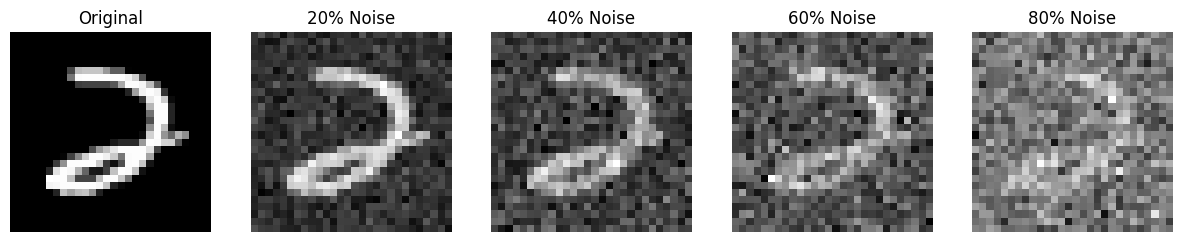

'\n# Try a non-linear noise schedule\nbeta_alt = torch.linspace(beta_start, beta_end, n_steps)**2\nalpha_alt = 1 - beta_alt\nalpha_bar_alt = torch.cumprod(alpha_alt, dim=0)\n# How would this affect the diffusion process?\n'

In [18]:
# Visualization function to show how noise progressively affects images
def show_noise_progression(image, num_steps=5):
    """
    Visualize how an image gets progressively noisier in the diffusion process.

    Args:
        image (torch.Tensor): Original clean image [C, H, W]
        num_steps (int): Number of noise levels to show
    """
    plt.figure(figsize=(15, 3))

    # Show original image
    plt.subplot(1, num_steps, 1)
    if IMG_CH == 1:  # Grayscale image
        plt.imshow(image[0].cpu(), cmap='gray')
    else:  # Color image
        img = image.permute(1, 2, 0).cpu()  # Change from [C,H,W] to [H,W,C]
        if img.min() < 0:  # If normalized between -1 and 1
            img = (img + 1) / 2  # Rescale to [0,1] for display
        plt.imshow(img)
    plt.title('Original')
    plt.axis('off')

    # Show progressively noisier versions
    for i in range(1, num_steps):
        # Calculate timestep index based on percentage through the process
        t_idx = int((i/num_steps) * n_steps)
        t = torch.tensor([t_idx]).to(device)

        # Add noise corresponding to timestep t
        noisy_image, _ = add_noise(image.unsqueeze(0), t)

        # Display the noisy image
        plt.subplot(1, num_steps, i+1)
        if IMG_CH == 1:
            plt.imshow(noisy_image[0][0].cpu(), cmap='gray')
        else:
            img = noisy_image[0].permute(1, 2, 0).cpu()
            if img.min() < 0:
                img = (img + 1) / 2
            plt.imshow(img)
        plt.title(f'{int((i/num_steps) * 100)}% Noise')
        plt.axis('off')
    plt.show()

# Show an example of noise progression on a real image
sample_batch = next(iter(train_dataloader))  # Get first batch
sample_image = sample_batch[0][0].to(device)  # Get first image
show_noise_progression(sample_image)

# Student Activity: Try different noise schedules
# Uncomment and modify these lines to experiment:
"""
# Try a non-linear noise schedule
beta_alt = torch.linspace(beta_start, beta_end, n_steps)**2
alpha_alt = 1 - beta_alt
alpha_bar_alt = torch.cumprod(alpha_alt, dim=0)
# How would this affect the diffusion process?
"""

## Step 5: Training Our Model

Now we'll teach our AI to generate images. This process:
1. Takes a clear image
2. Adds random noise to it
3. Asks our AI to predict what noise was added
4. Helps our AI learn from its mistakes

This will take a while, but we'll see progress as it learns!

In [19]:
# Define helper functions needed for training and evaluation
def validate_model_parameters(model):
    """
    Counts model parameters and estimates memory usage.
    """
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Estimate memory requirements (very approximate)
    param_memory = total_params * 4 / (1024 ** 2)  # MB for params (float32)
    grad_memory = trainable_params * 4 / (1024 ** 2)  # MB for gradients
    buffer_memory = param_memory * 2  # Optimizer state, forward activations, etc.

    print(f"Estimated GPU memory usage: {param_memory + grad_memory + buffer_memory:.1f} MB")

# Define helper functions for verifying data ranges
def verify_data_range(dataloader, name="Dataset"):
    """
    Verifies the range and integrity of the data.
    """
    batch = next(iter(dataloader))[0]
    print(f"\n{name} range check:")
    print(f"Shape: {batch.shape}")
    print(f"Data type: {batch.dtype}")
    print(f"Min value: {batch.min().item():.2f}")
    print(f"Max value: {batch.max().item():.2f}")
    print(f"Contains NaN: {torch.isnan(batch).any().item()}")
    print(f"Contains Inf: {torch.isinf(batch).any().item()}")

# Define helper functions for generating samples during training
def generate_samples(model, n_samples=10):
    """
    Generates sample images using the model for visualization during training.
    """
    model.eval()
    with torch.no_grad():
        # Generate digits 0-9 for visualization
        samples = []
        for digit in range(min(n_samples, 10)):
            # Start with random noise
            x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

            # Set up conditioning for the digit
            c = torch.tensor([digit]).to(device)
            c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
            c_mask = torch.ones_like(c.unsqueeze(-1)).float().to(device) # Added .float()

            # Remove noise step by step
            for t in range(n_steps-1, -1, -1):
                t_batch = torch.full((1,), t).to(device)
                x = remove_noise(x, t_batch, model, c_one_hot, c_mask)

            samples.append(x)

        # Combine samples and display
        samples = torch.cat(samples, dim=0)
        grid = make_grid(samples, nrow=min(n_samples, 5), normalize=True)

        plt.figure(figsize=(10, 4))

        # Display based on channel configuration
        if IMG_CH == 1:
            plt.imshow(grid[0].cpu(), cmap='gray')
        else:
            plt.imshow(grid.permute(1, 2, 0).cpu())

        plt.axis('off')
        plt.title('Generated Samples')
        plt.show()

# Define helper functions for safely saving models
def safe_save_model(model, path, optimizer=None, epoch=None, best_loss=None):
    """
    Safely saves model with error handling and backup.
    """
    try:
        # Create a dictionary with all the elements to save
        save_dict = {
            'model_state_dict': model.state_dict(),
        }

        # Add optional elements if provided
        if optimizer is not None:
            save_dict['optimizer_state_dict'] = optimizer.state_dict()
        if epoch is not None:
            save_dict['epoch'] = epoch
        if best_loss is not None:
            save_dict['best_loss'] = best_loss

        # Create a backup of previous checkpoint if it exists
        if os.path.exists(path):
            backup_path = path + '.backup'
            try:
                os.replace(path, backup_path)
                print(f"Created backup at {backup_path}")
            except Exception as e:
                print(f"Warning: Could not create backup - {e}")

        # Save the new checkpoint
        torch.save(save_dict, path)
        print(f"Model successfully saved to {path}")

    except Exception as e:
        print(f"Error saving model: {e}")
        print("Attempting emergency save...")

        try:
            emergency_path = path + '.emergency'
            torch.save(model.state_dict(), emergency_path)
            print(f"Emergency save successful: {emergency_path}")
        except:
            print("Emergency save failed. Could not save model.")

# Create our model and move it to GPU if available
model = UNet(
    T=n_steps,                 # Number of diffusion time steps
    img_ch=IMG_CH,             # Number of channels in our images (1 for grayscale, 3 for RGB)
    img_size=IMG_SIZE,         # Size of input images (28 for MNIST, 32 for CIFAR-10)
    down_chs=(32, 64, 128),    # Channel dimensions for each downsampling level
    t_embed_dim=8,             # Dimension for time step embeddings
    c_embed_dim=N_CLASSES      # Number of classes for conditioning
).to(device)

# Print model summary
print(f"\n{'='*50}")
print(f"MODEL ARCHITECTURE SUMMARY")
print(f"{'='*50}")
print(f"Input resolution: {IMG_SIZE}x{IMG_SIZE}")
print(f"Input channels: {IMG_CH}")
print(f"Time steps: {n_steps}")
print(f"Condition classes: {N_CLASSES}")
print(f"GPU acceleration: {'Yes' if device.type == 'cuda' else 'No'}")

# Validate model parameters and estimate memory requirements
validate_model_parameters(model)

# Verify data ranges and integrity
verify_data_range(train_dataloader, "Training Data")
verify_data_range(val_dataloader, "Validation Data")


# Set up the optimizer with parameters tuned for diffusion models
# Note: Lower learning rates tend to work better for diffusion models
initial_lr = 0.001  # Starting learning rate
weight_decay = 1e-5  # L2 regularization to prevent overfitting

optimizer = Adam(
    model.parameters(),
    lr=initial_lr,
    weight_decay=weight_decay
)

# Learning rate scheduler to reduce LR when validation loss plateaus
# This helps fine-tune the model toward the end of training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',              # Reduce LR when monitored value stops decreasing
    factor=0.5,              # Multiply LR by this factor
    patience=5,              # Number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6              # Lower bound on the learning rate
)

# STUDENT EXPERIMENT:
# Try different channel configurations and see how they affect:
# 1. Model size (parameter count)
# 2. Training time
# 3. Generated image quality
#
# Suggestions:
# - Smaller: down_chs=(16, 32, 64)
# - Larger: down_chs=(64, 128, 256, 512)

Created DownBlock: in_chs=32, out_chs=64, spatial_reduction=2x
Created DownBlock: in_chs=64, out_chs=128, spatial_reduction=2x
Created UpBlock: in_chs=128, out_chs=64, spatial_increase=2x
Created UpBlock: in_chs=64, out_chs=32, spatial_increase=2x
Created UNet with 3 scale levels
Channel dimensions: (32, 64, 128)

MODEL ARCHITECTURE SUMMARY
Input resolution: 28x28
Input channels: 1
Time steps: 100
Condition classes: 10
GPU acceleration: Yes
Total parameters: 1,518,737
Trainable parameters: 1,518,737
Estimated GPU memory usage: 23.2 MB

Training Data range check:
Shape: torch.Size([64, 1, 28, 28])
Data type: torch.float32
Min value: -1.00
Max value: 1.00
Contains NaN: False
Contains Inf: False

Validation Data range check:
Shape: torch.Size([64, 1, 28, 28])
Data type: torch.float32
Min value: -1.00
Max value: 1.00
Contains NaN: False
Contains Inf: False


In [20]:
# Define helper functions needed for training and evaluation
def validate_model_parameters(model):
    """
    Counts model parameters and estimates memory usage.
    """
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Estimate memory requirements (very approximate)
    param_memory = total_params * 4 / (1024 ** 2)  # MB for params (float32)
    grad_memory = trainable_params * 4 / (1024 ** 2)  # MB for gradients
    buffer_memory = param_memory * 2  # Optimizer state, forward activations, etc.

    print(f"Estimated GPU memory usage: {param_memory + grad_memory + buffer_memory:.1f} MB")

# Define helper functions for verifying data ranges
def verify_data_range(dataloader, name="Dataset"):
    """
    Verifies the range and integrity of the data.
    """
    batch = next(iter(dataloader))[0]
    print(f"\n{name} range check:")
    print(f"Shape: {batch.shape}")
    print(f"Data type: {batch.dtype}")
    print(f"Min value: {batch.min().item():.2f}")
    print(f"Max value: {batch.max().item():.2f}")
    print(f"Contains NaN: {torch.isnan(batch).any().item()}")
    print(f"Contains Inf: {torch.isinf(batch).any().item()}")

# Define helper functions for generating samples during training
def generate_samples(model, n_samples=10):
    """
    Generates sample images using the model for visualization during training.
    """
    model.eval()
    with torch.no_grad():
        # Generate digits 0-9 for visualization
        samples = []
        for digit in range(min(n_samples, 10)):
            # Start with random noise
            x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

            # Set up conditioning for the digit
            c = torch.tensor([digit]).to(device)
            c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
            c_mask = torch.ones_like(c.unsqueeze(-1)).float().to(device) # Ensure c_mask is float

            # Remove noise step by step
            for t in range(n_steps-1, -1, -1):
                t_batch = torch.full((1,), t).to(device)
                x = remove_noise(x, t_batch, model, c_one_hot, c_mask)

            samples.append(x)

        # Combine samples and display
        samples = torch.cat(samples, dim=0)
        grid = make_grid(samples, nrow=min(n_samples, 5), normalize=True)

        plt.figure(figsize=(10, 4))

        # Display based on channel configuration
        if IMG_CH == 1:
            plt.imshow(grid[0].cpu(), cmap='gray')
        else:
            plt.imshow(grid.permute(1, 2, 0).cpu())

        plt.axis('off')
        plt.title('Generated Samples')
        plt.show()

# Define helper functions for safely saving models
def safe_save_model(model, path, optimizer=None, epoch=None, best_loss=None):
    """
    Safely saves model with error handling and backup.
    """
    try:
        # Create a dictionary with all the elements to save
        save_dict = {
            'model_state_dict': model.state_dict(),
        }

        # Add optional elements if provided
        if optimizer is not None:
            save_dict['optimizer_state_dict'] = optimizer.state_dict()
        if epoch is not None:
            save_dict['epoch'] = epoch
        if best_loss is not None:
            save_dict['best_loss'] = best_loss

        # Create a backup of previous checkpoint if it exists
        if os.path.exists(path):
            backup_path = path + '.backup'
            try:
                os.replace(path, backup_path)
                print(f"Created backup at {backup_path}")
            except Exception as e:
                print(f"Warning: Could not create backup - {e}")

        # Save the new checkpoint
        torch.save(save_dict, path)
        print(f"Model successfully saved to {path}")

    except Exception as e:
        print(f"Error saving model: {e}")
        print("Attempting emergency save...")

        try:
            emergency_path = path + '.emergency'
            torch.save(model.state_dict(), emergency_path)
            print(f"Emergency save successful: {emergency_path}")
        except:
            print("Emergency save failed. Could not save model.")

In [21]:
#  Implementation of the training step function
def train_step(x, c):
    """
    Performs a single training step for the diffusion model.

    This function:
    1. Prepares class conditioning
    2. Samples random timesteps for each image
    3. Adds corresponding noise to the images
    4. Asks the model to predict the noise
    5. Calculates the loss between predicted and actual noise

    Args:
        x (torch.Tensor): Batch of clean images [batch_size, channels, height, width]
        c (torch.Tensor): Batch of class labels [batch_size]

    Returns:
        torch.Tensor: Mean squared error loss value
    """
    # Convert number labels to one-hot encoding for class conditioning
    c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)

    # Create conditioning mask (all ones for standard training)
    c_mask = torch.ones_like(c.unsqueeze(-1)).to(device)

    # Pick random timesteps for each image in the batch
    t = torch.randint(0, n_steps, (x.shape[0],)).to(device)

    # Add noise to images according to the forward diffusion process
    x_t, noise = add_noise(x, t)

    # The model tries to predict the exact noise that was added
    predicted_noise = model(x_t, t, c_one_hot, c_mask)

    # Calculate loss: MSE between predicted and actual noise
    loss = F.mse_loss(predicted_noise, noise)
    return loss



STARTING TRAINING

Epoch 1/30
--------------------
  Step 0/750, Loss: 1.1178
  Step 100/750, Loss: 0.1382
  Step 200/750, Loss: 0.1064
  Step 300/750, Loss: 0.0860
  Step 400/750, Loss: 0.0956
  Step 500/750, Loss: 0.0790
  Generating samples...


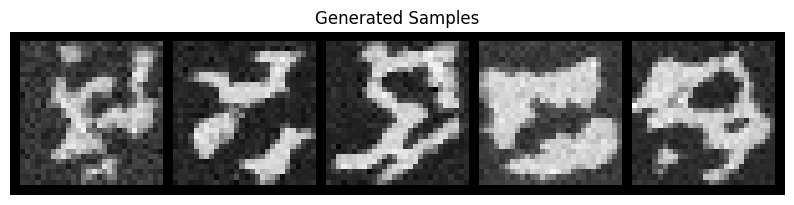

  Step 600/750, Loss: 0.0579
  Step 700/750, Loss: 0.0703

Training - Epoch 1 average loss: 0.1001
Running validation...
Validation - Epoch 1 average loss: 0.0738
Learning rate: 0.001000

Generating samples for visual progress check...


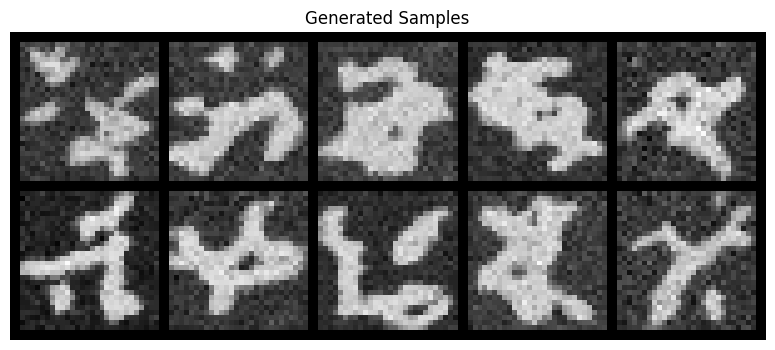

Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0738)


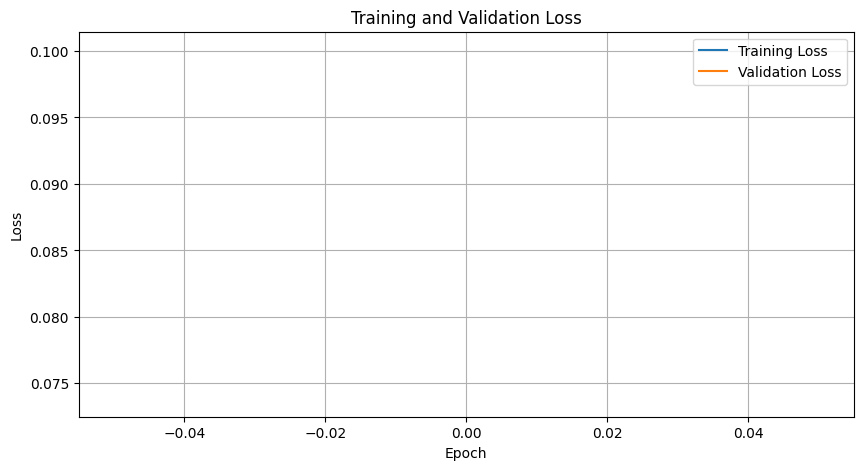


Epoch 2/30
--------------------
  Step 0/750, Loss: 0.0729
  Step 100/750, Loss: 0.0731
  Step 200/750, Loss: 0.0768
  Step 300/750, Loss: 0.0614
  Step 400/750, Loss: 0.0625
  Step 500/750, Loss: 0.0579
  Generating samples...


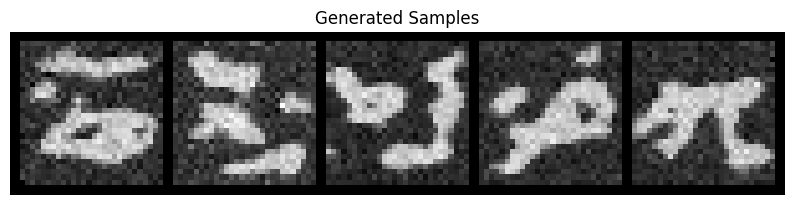

  Step 600/750, Loss: 0.0655
  Step 700/750, Loss: 0.0690

Training - Epoch 2 average loss: 0.0704
Running validation...
Validation - Epoch 2 average loss: 0.0678
Learning rate: 0.001000
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0678)

Epoch 3/30
--------------------
  Step 0/750, Loss: 0.0731
  Step 100/750, Loss: 0.0667
  Step 200/750, Loss: 0.0692
  Step 300/750, Loss: 0.0647
  Step 400/750, Loss: 0.0689
  Step 500/750, Loss: 0.0673
  Generating samples...


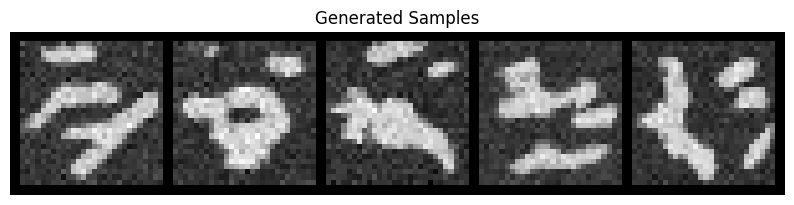

  Step 600/750, Loss: 0.0758
  Step 700/750, Loss: 0.0621

Training - Epoch 3 average loss: 0.0668
Running validation...
Validation - Epoch 3 average loss: 0.0658
Learning rate: 0.001000

Generating samples for visual progress check...


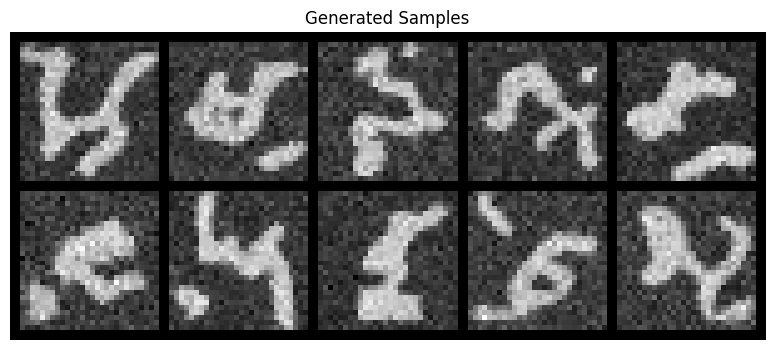

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0658)

Epoch 4/30
--------------------
  Step 0/750, Loss: 0.0600
  Step 100/750, Loss: 0.0666
  Step 200/750, Loss: 0.0566
  Step 300/750, Loss: 0.0662
  Step 400/750, Loss: 0.0596
  Step 500/750, Loss: 0.0673
  Generating samples...


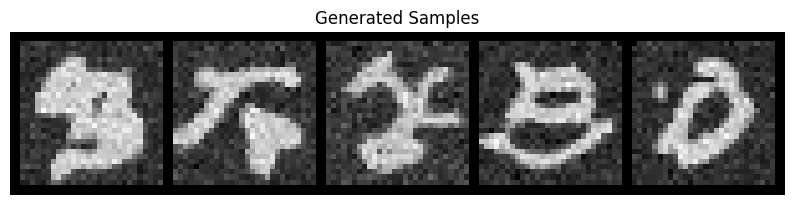

  Step 600/750, Loss: 0.0688
  Step 700/750, Loss: 0.0684

Training - Epoch 4 average loss: 0.0640
Running validation...
Validation - Epoch 4 average loss: 0.0629
Learning rate: 0.001000
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0629)

Epoch 5/30
--------------------
  Step 0/750, Loss: 0.0590
  Step 100/750, Loss: 0.0625
  Step 200/750, Loss: 0.0689
  Step 300/750, Loss: 0.0530
  Step 400/750, Loss: 0.0528
  Step 500/750, Loss: 0.0649
  Generating samples...


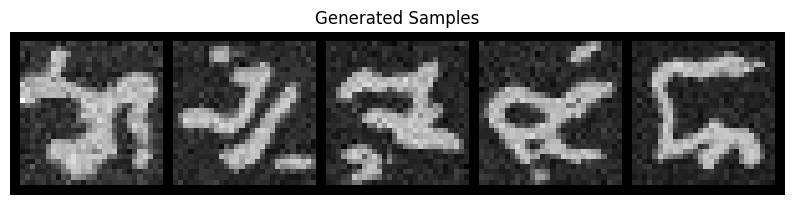

  Step 600/750, Loss: 0.0596
  Step 700/750, Loss: 0.0708

Training - Epoch 5 average loss: 0.0628
Running validation...
Validation - Epoch 5 average loss: 0.0621
Learning rate: 0.001000

Generating samples for visual progress check...


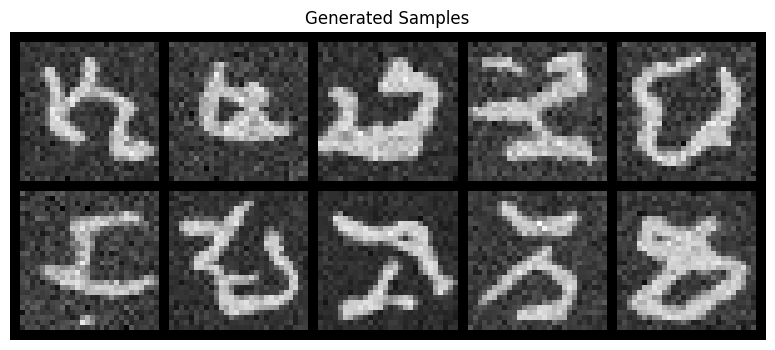

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0621)

Epoch 6/30
--------------------
  Step 0/750, Loss: 0.0552
  Step 100/750, Loss: 0.0595
  Step 200/750, Loss: 0.0637
  Step 300/750, Loss: 0.0524
  Step 400/750, Loss: 0.0608
  Step 500/750, Loss: 0.0650
  Generating samples...


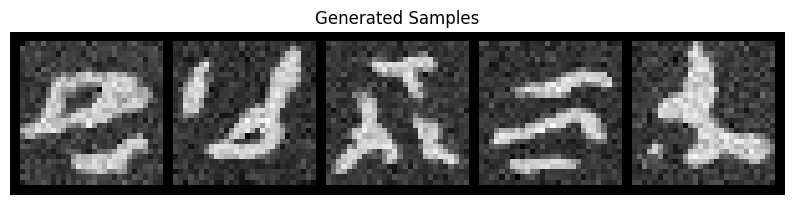

  Step 600/750, Loss: 0.0599
  Step 700/750, Loss: 0.0606

Training - Epoch 6 average loss: 0.0620
Running validation...
Validation - Epoch 6 average loss: 0.0607
Learning rate: 0.001000
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0607)


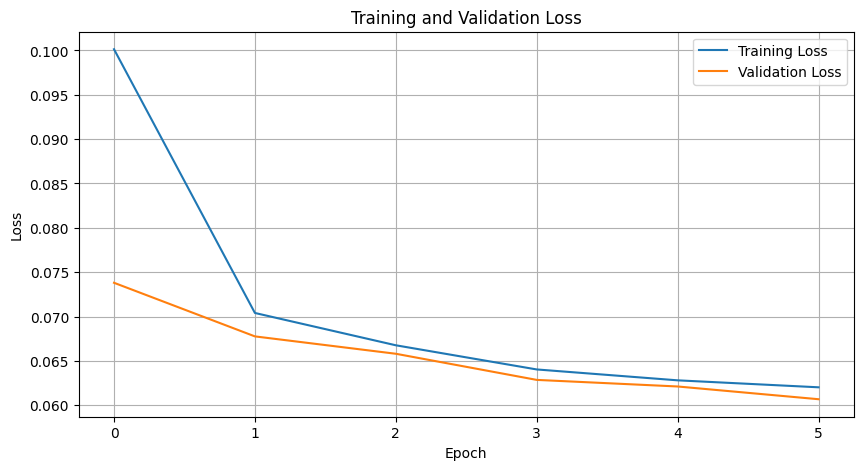


Epoch 7/30
--------------------
  Step 0/750, Loss: 0.0599
  Step 100/750, Loss: 0.0684
  Step 200/750, Loss: 0.0613
  Step 300/750, Loss: 0.0605
  Step 400/750, Loss: 0.0602
  Step 500/750, Loss: 0.0648
  Generating samples...


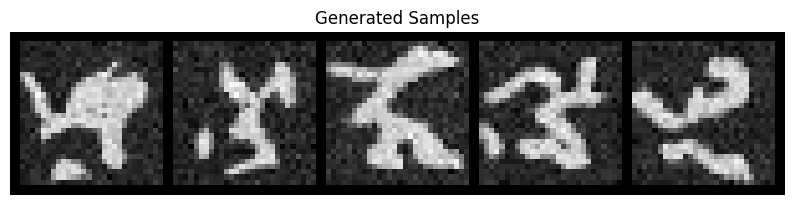

  Step 600/750, Loss: 0.0622
  Step 700/750, Loss: 0.0648

Training - Epoch 7 average loss: 0.0614
Running validation...
Validation - Epoch 7 average loss: 0.0595
Learning rate: 0.001000

Generating samples for visual progress check...


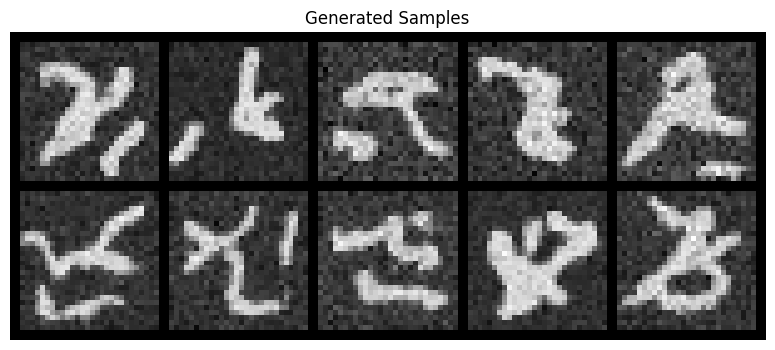

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0595)

Epoch 8/30
--------------------
  Step 0/750, Loss: 0.0586
  Step 100/750, Loss: 0.0591
  Step 200/750, Loss: 0.0591
  Step 300/750, Loss: 0.0637
  Step 400/750, Loss: 0.0604
  Step 500/750, Loss: 0.0602
  Generating samples...


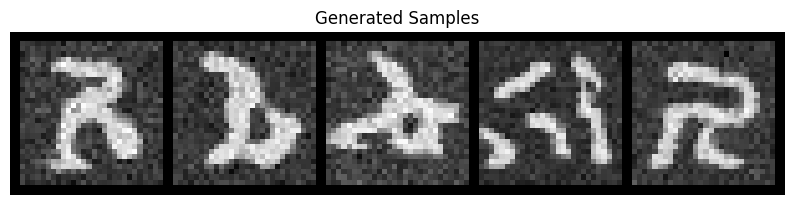

  Step 600/750, Loss: 0.0620
  Step 700/750, Loss: 0.0669

Training - Epoch 8 average loss: 0.0605
Running validation...
Validation - Epoch 8 average loss: 0.0595
Learning rate: 0.001000
No improvement for 1/10 epochs

Epoch 9/30
--------------------
  Step 0/750, Loss: 0.0506
  Step 100/750, Loss: 0.0762
  Step 200/750, Loss: 0.0636
  Step 300/750, Loss: 0.0608
  Step 400/750, Loss: 0.0610
  Step 500/750, Loss: 0.0645
  Generating samples...


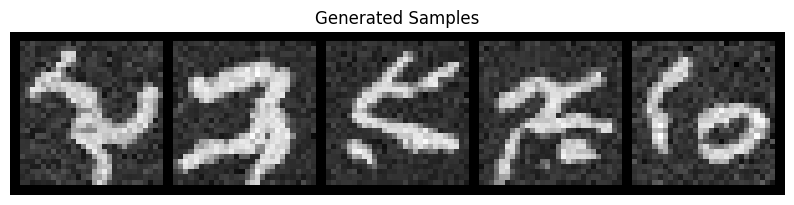

  Step 600/750, Loss: 0.0628
  Step 700/750, Loss: 0.0575

Training - Epoch 9 average loss: 0.0601
Running validation...
Validation - Epoch 9 average loss: 0.0588
Learning rate: 0.001000

Generating samples for visual progress check...


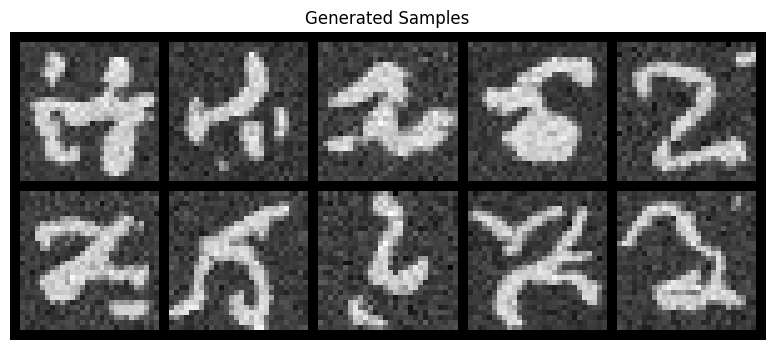

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0588)

Epoch 10/30
--------------------
  Step 0/750, Loss: 0.0537
  Step 100/750, Loss: 0.0602
  Step 200/750, Loss: 0.0589
  Step 300/750, Loss: 0.0650
  Step 400/750, Loss: 0.0622
  Step 500/750, Loss: 0.0567
  Generating samples...


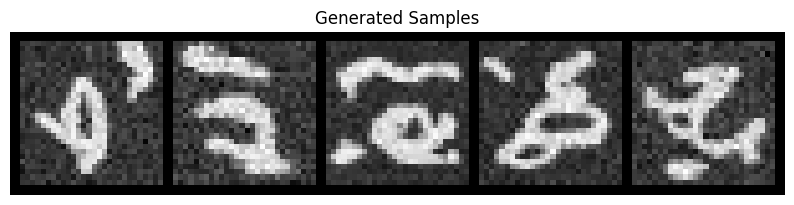

  Step 600/750, Loss: 0.0574
  Step 700/750, Loss: 0.0579

Training - Epoch 10 average loss: 0.0600
Running validation...
Validation - Epoch 10 average loss: 0.0593
Learning rate: 0.001000
No improvement for 1/10 epochs

Epoch 11/30
--------------------
  Step 0/750, Loss: 0.0599
  Step 100/750, Loss: 0.0692
  Step 200/750, Loss: 0.0606
  Step 300/750, Loss: 0.0517
  Step 400/750, Loss: 0.0608
  Step 500/750, Loss: 0.0526
  Generating samples...


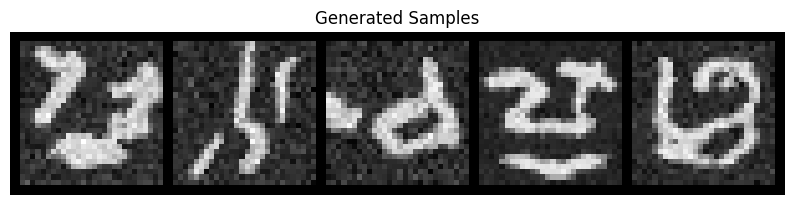

  Step 600/750, Loss: 0.0592
  Step 700/750, Loss: 0.0567

Training - Epoch 11 average loss: 0.0594
Running validation...
Validation - Epoch 11 average loss: 0.0596
Learning rate: 0.001000

Generating samples for visual progress check...


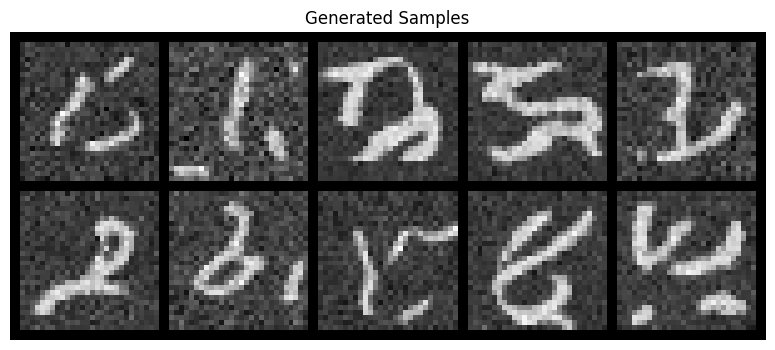

No improvement for 2/10 epochs


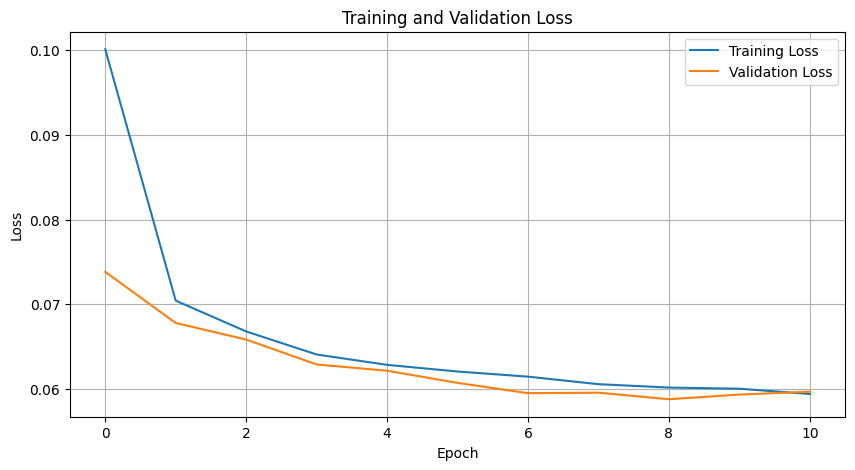


Epoch 12/30
--------------------
  Step 0/750, Loss: 0.0610
  Step 100/750, Loss: 0.0604
  Step 200/750, Loss: 0.0574
  Step 300/750, Loss: 0.0626
  Step 400/750, Loss: 0.0623
  Step 500/750, Loss: 0.0527
  Generating samples...


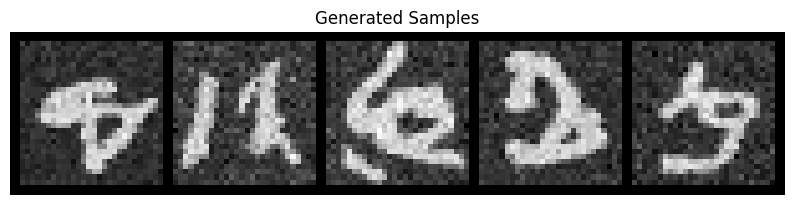

  Step 600/750, Loss: 0.0545
  Step 700/750, Loss: 0.0577

Training - Epoch 12 average loss: 0.0590
Running validation...
Validation - Epoch 12 average loss: 0.0580
Learning rate: 0.001000
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0580)

Epoch 13/30
--------------------
  Step 0/750, Loss: 0.0626
  Step 100/750, Loss: 0.0601
  Step 200/750, Loss: 0.0627
  Step 300/750, Loss: 0.0602
  Step 400/750, Loss: 0.0565
  Step 500/750, Loss: 0.0645
  Generating samples...


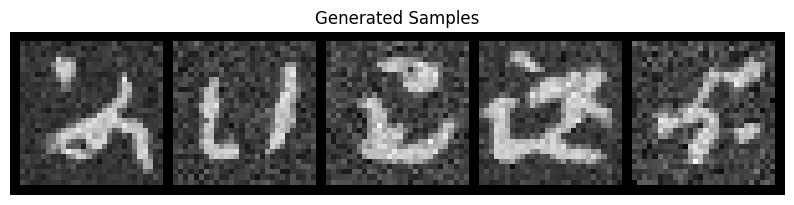

  Step 600/750, Loss: 0.0543
  Step 700/750, Loss: 0.0579

Training - Epoch 13 average loss: 0.0590
Running validation...
Validation - Epoch 13 average loss: 0.0578
Learning rate: 0.001000

Generating samples for visual progress check...


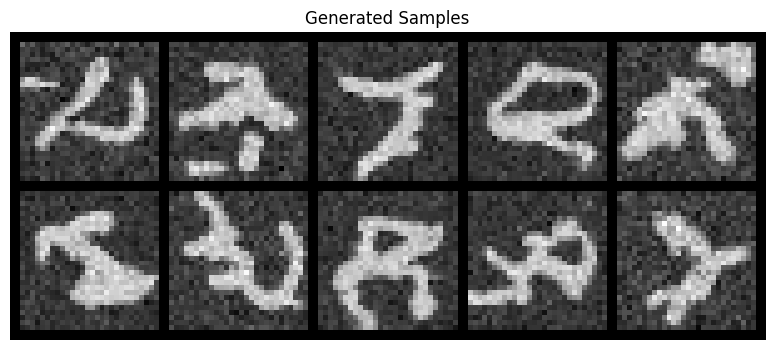

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0578)

Epoch 14/30
--------------------
  Step 0/750, Loss: 0.0616
  Step 100/750, Loss: 0.0588
  Step 200/750, Loss: 0.0634
  Step 300/750, Loss: 0.0551
  Step 400/750, Loss: 0.0557
  Step 500/750, Loss: 0.0583
  Generating samples...


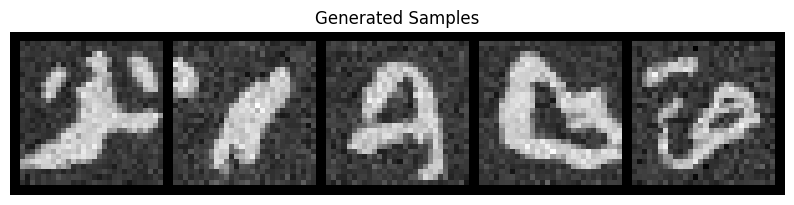

  Step 600/750, Loss: 0.0586
  Step 700/750, Loss: 0.0497

Training - Epoch 14 average loss: 0.0586
Running validation...
Validation - Epoch 14 average loss: 0.0586
Learning rate: 0.001000
No improvement for 1/10 epochs

Epoch 15/30
--------------------
  Step 0/750, Loss: 0.0604
  Step 100/750, Loss: 0.0651
  Step 200/750, Loss: 0.0580
  Step 300/750, Loss: 0.0517
  Step 400/750, Loss: 0.0579
  Step 500/750, Loss: 0.0534
  Generating samples...


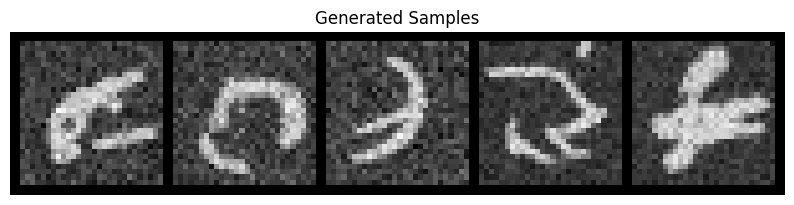

  Step 600/750, Loss: 0.0617
  Step 700/750, Loss: 0.0649

Training - Epoch 15 average loss: 0.0586
Running validation...
Validation - Epoch 15 average loss: 0.0585
Learning rate: 0.001000

Generating samples for visual progress check...


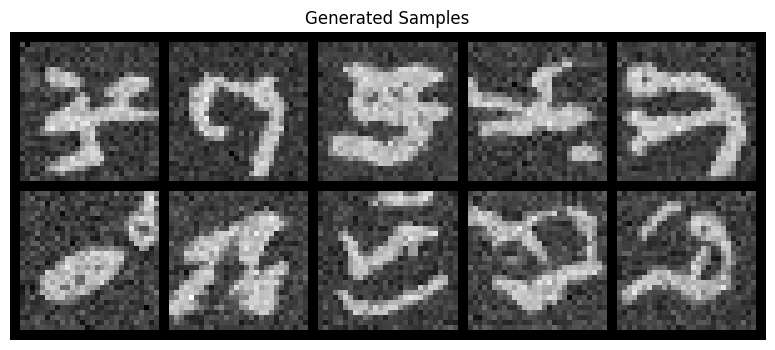

No improvement for 2/10 epochs

Epoch 16/30
--------------------
  Step 0/750, Loss: 0.0551
  Step 100/750, Loss: 0.0523
  Step 200/750, Loss: 0.0584
  Step 300/750, Loss: 0.0573
  Step 400/750, Loss: 0.0641
  Step 500/750, Loss: 0.0583
  Generating samples...


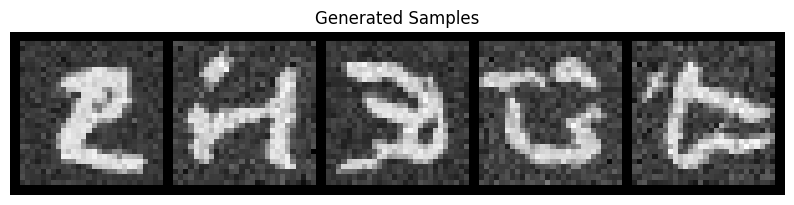

  Step 600/750, Loss: 0.0640
  Step 700/750, Loss: 0.0645

Training - Epoch 16 average loss: 0.0587
Running validation...
Validation - Epoch 16 average loss: 0.0582
Learning rate: 0.001000
No improvement for 3/10 epochs


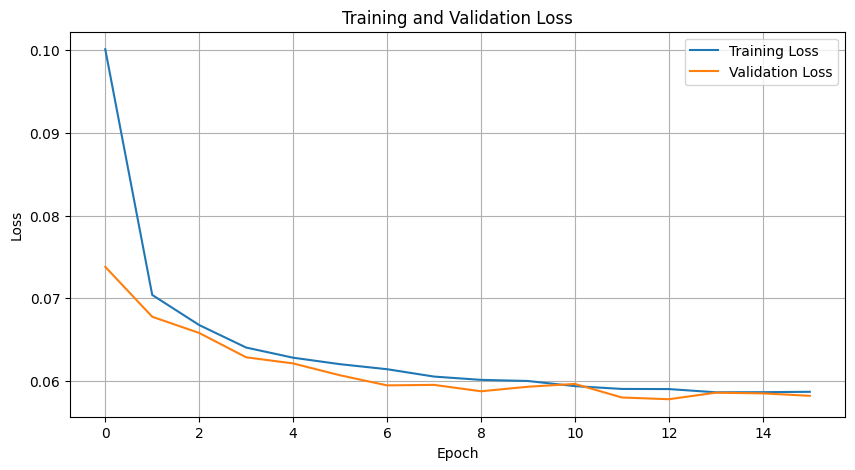


Epoch 17/30
--------------------
  Step 0/750, Loss: 0.0536
  Step 100/750, Loss: 0.0608
  Step 200/750, Loss: 0.0571
  Step 300/750, Loss: 0.0548
  Step 400/750, Loss: 0.0611
  Step 500/750, Loss: 0.0548
  Generating samples...


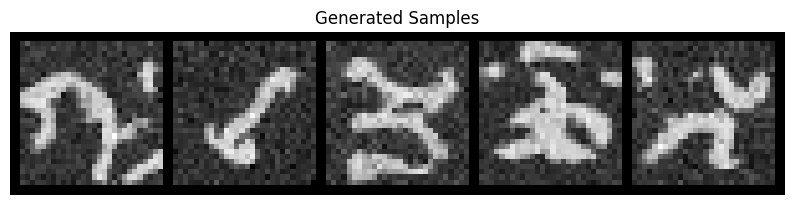

  Step 600/750, Loss: 0.0579
  Step 700/750, Loss: 0.0540

Training - Epoch 17 average loss: 0.0585
Running validation...
Validation - Epoch 17 average loss: 0.0582
Learning rate: 0.001000

Generating samples for visual progress check...


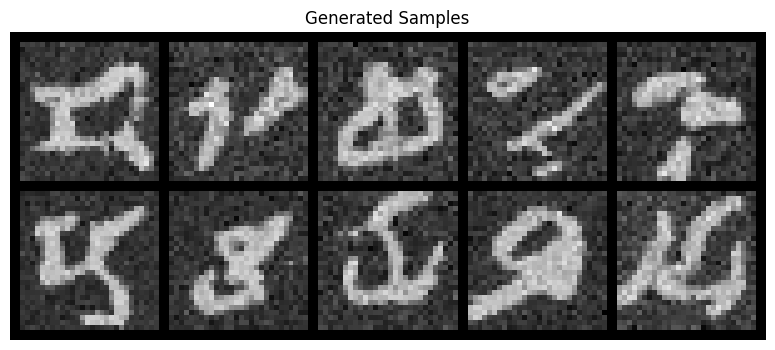

No improvement for 4/10 epochs

Epoch 18/30
--------------------
  Step 0/750, Loss: 0.0532
  Step 100/750, Loss: 0.0593
  Step 200/750, Loss: 0.0667
  Step 300/750, Loss: 0.0623
  Step 400/750, Loss: 0.0576
  Step 500/750, Loss: 0.0490
  Generating samples...


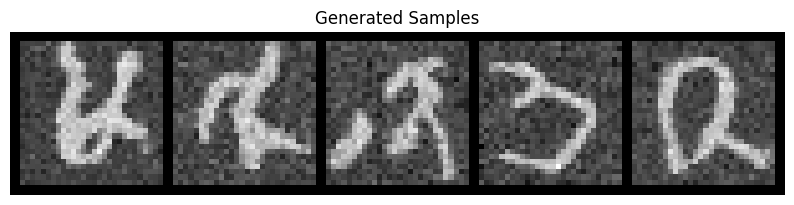

  Step 600/750, Loss: 0.0550
  Step 700/750, Loss: 0.0587

Training - Epoch 18 average loss: 0.0583
Running validation...
Validation - Epoch 18 average loss: 0.0571
Learning rate: 0.001000
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0571)

Epoch 19/30
--------------------
  Step 0/750, Loss: 0.0617
  Step 100/750, Loss: 0.0612
  Step 200/750, Loss: 0.0577
  Step 300/750, Loss: 0.0607
  Step 400/750, Loss: 0.0501
  Step 500/750, Loss: 0.0648
  Generating samples...


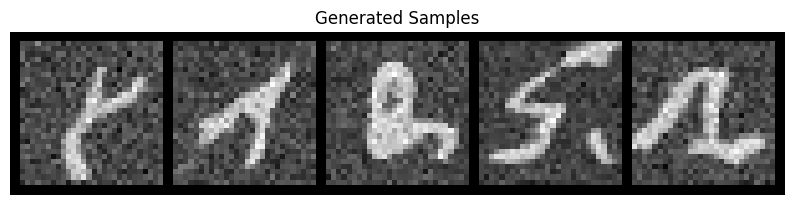

  Step 600/750, Loss: 0.0501
  Step 700/750, Loss: 0.0604

Training - Epoch 19 average loss: 0.0578
Running validation...
Validation - Epoch 19 average loss: 0.0579
Learning rate: 0.001000

Generating samples for visual progress check...


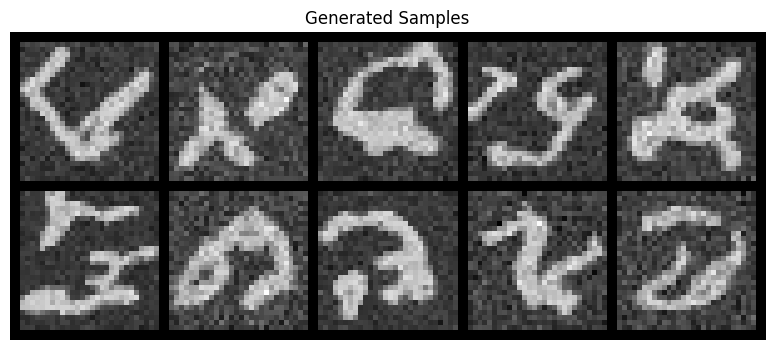

No improvement for 1/10 epochs

Epoch 20/30
--------------------
  Step 0/750, Loss: 0.0555
  Step 100/750, Loss: 0.0556
  Step 200/750, Loss: 0.0619
  Step 300/750, Loss: 0.0598
  Step 400/750, Loss: 0.0574
  Step 500/750, Loss: 0.0612
  Generating samples...


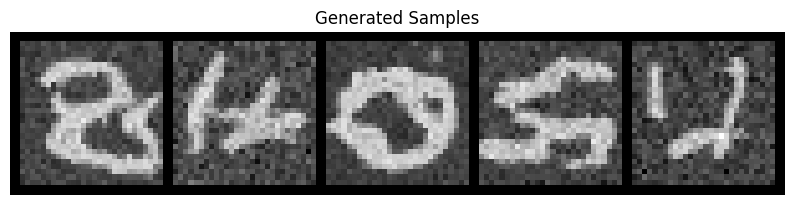

  Step 600/750, Loss: 0.0545
  Step 700/750, Loss: 0.0581

Training - Epoch 20 average loss: 0.0578
Running validation...
Validation - Epoch 20 average loss: 0.0565
Learning rate: 0.001000
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0565)

Epoch 21/30
--------------------
  Step 0/750, Loss: 0.0612
  Step 100/750, Loss: 0.0526
  Step 200/750, Loss: 0.0552
  Step 300/750, Loss: 0.0635
  Step 400/750, Loss: 0.0571
  Step 500/750, Loss: 0.0559
  Generating samples...


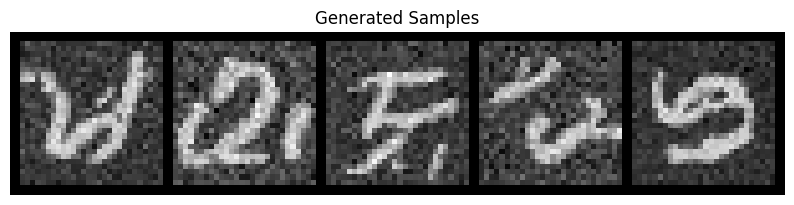

  Step 600/750, Loss: 0.0516
  Step 700/750, Loss: 0.0510

Training - Epoch 21 average loss: 0.0576
Running validation...
Validation - Epoch 21 average loss: 0.0579
Learning rate: 0.001000

Generating samples for visual progress check...


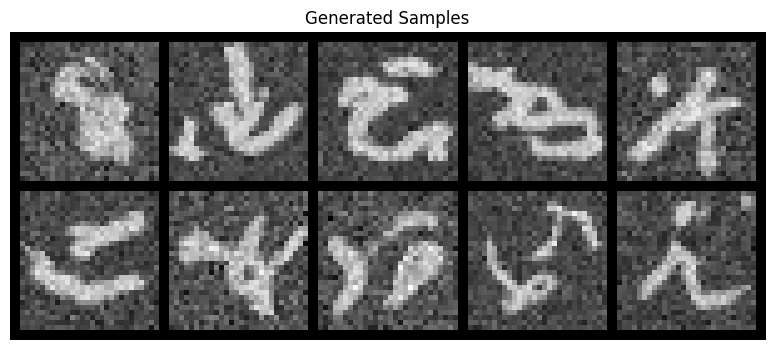

No improvement for 1/10 epochs


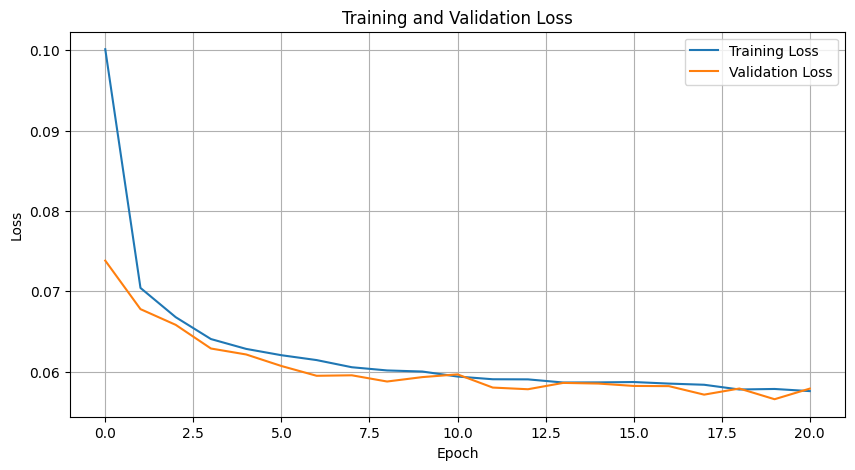


Epoch 22/30
--------------------
  Step 0/750, Loss: 0.0586
  Step 100/750, Loss: 0.0567
  Step 200/750, Loss: 0.0529
  Step 300/750, Loss: 0.0507
  Step 400/750, Loss: 0.0522
  Step 500/750, Loss: 0.0604
  Generating samples...


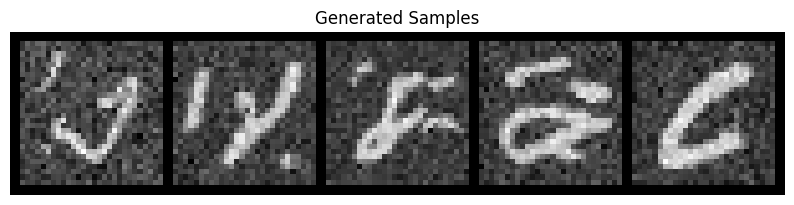

  Step 600/750, Loss: 0.0540
  Step 700/750, Loss: 0.0556

Training - Epoch 22 average loss: 0.0577
Running validation...
Validation - Epoch 22 average loss: 0.0576
Learning rate: 0.001000
No improvement for 2/10 epochs

Epoch 23/30
--------------------
  Step 0/750, Loss: 0.0585
  Step 100/750, Loss: 0.0547
  Step 200/750, Loss: 0.0584
  Step 300/750, Loss: 0.0567
  Step 400/750, Loss: 0.0640
  Step 500/750, Loss: 0.0567
  Generating samples...


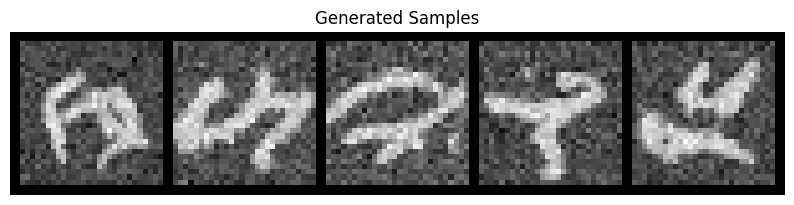

  Step 600/750, Loss: 0.0573
  Step 700/750, Loss: 0.0579

Training - Epoch 23 average loss: 0.0579
Running validation...
Validation - Epoch 23 average loss: 0.0583
Learning rate: 0.001000

Generating samples for visual progress check...


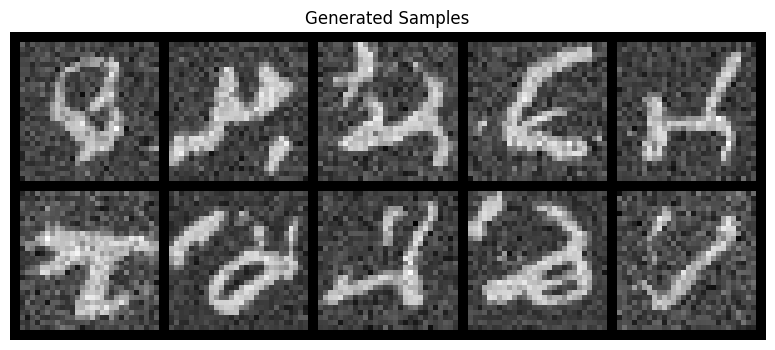

No improvement for 3/10 epochs

Epoch 24/30
--------------------
  Step 0/750, Loss: 0.0526
  Step 100/750, Loss: 0.0601
  Step 200/750, Loss: 0.0567
  Step 300/750, Loss: 0.0573
  Step 400/750, Loss: 0.0581
  Step 500/750, Loss: 0.0598
  Generating samples...


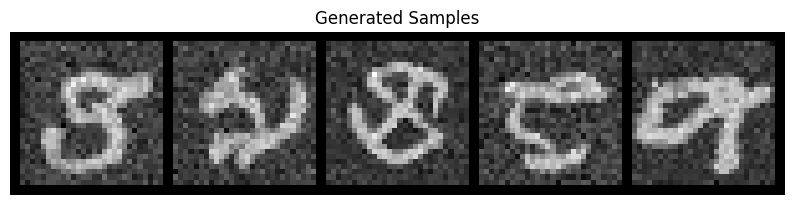

  Step 600/750, Loss: 0.0565
  Step 700/750, Loss: 0.0623

Training - Epoch 24 average loss: 0.0572
Running validation...
Validation - Epoch 24 average loss: 0.0578
Learning rate: 0.001000
No improvement for 4/10 epochs

Epoch 25/30
--------------------
  Step 0/750, Loss: 0.0651
  Step 100/750, Loss: 0.0602
  Step 200/750, Loss: 0.0551
  Step 300/750, Loss: 0.0548
  Step 400/750, Loss: 0.0642
  Step 500/750, Loss: 0.0680
  Generating samples...


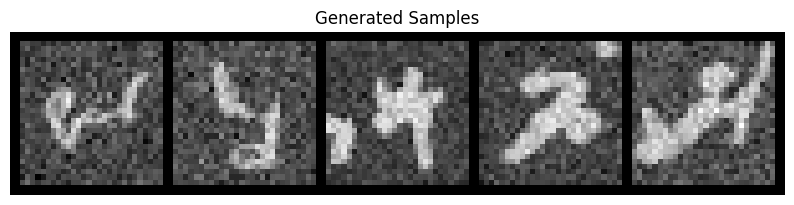

  Step 600/750, Loss: 0.0550
  Step 700/750, Loss: 0.0657

Training - Epoch 25 average loss: 0.0574
Running validation...
Validation - Epoch 25 average loss: 0.0573
Learning rate: 0.001000

Generating samples for visual progress check...


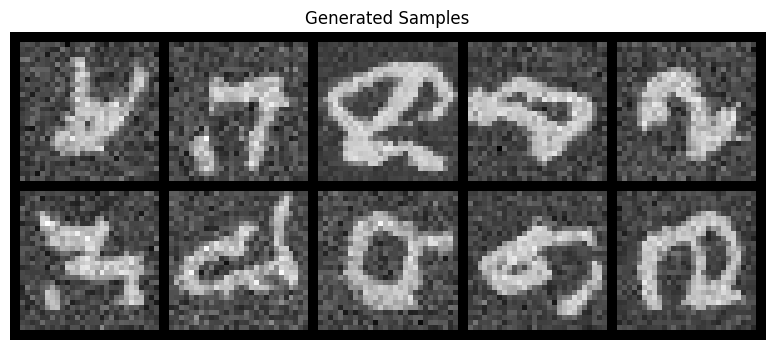

No improvement for 5/10 epochs

Epoch 26/30
--------------------
  Step 0/750, Loss: 0.0537
  Step 100/750, Loss: 0.0591
  Step 200/750, Loss: 0.0542
  Step 300/750, Loss: 0.0564
  Step 400/750, Loss: 0.0569
  Step 500/750, Loss: 0.0502
  Generating samples...


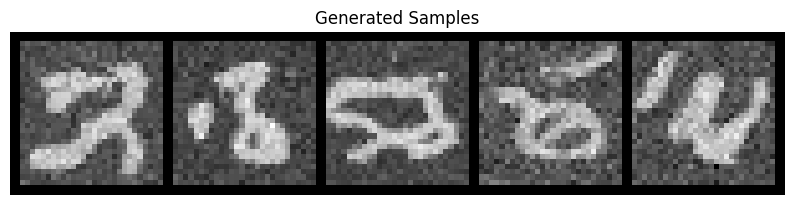

  Step 600/750, Loss: 0.0555
  Step 700/750, Loss: 0.0599

Training - Epoch 26 average loss: 0.0573
Running validation...
Validation - Epoch 26 average loss: 0.0570
Learning rate: 0.000500
No improvement for 6/10 epochs


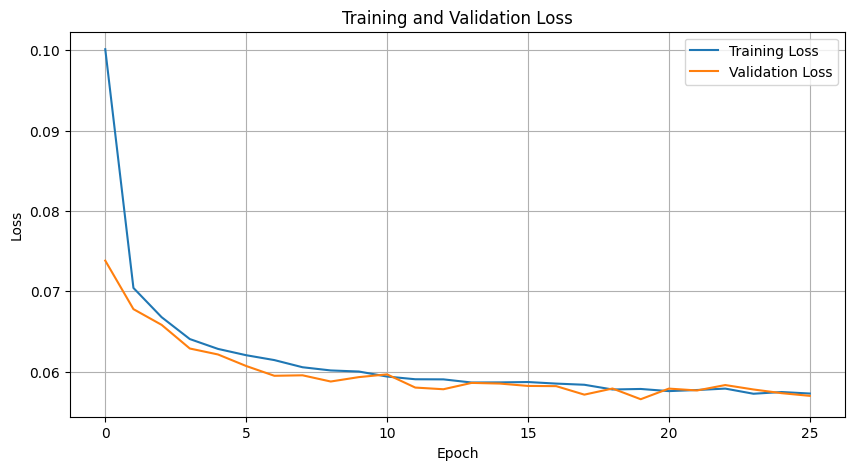


Epoch 27/30
--------------------
  Step 0/750, Loss: 0.0529
  Step 100/750, Loss: 0.0494
  Step 200/750, Loss: 0.0668
  Step 300/750, Loss: 0.0634
  Step 400/750, Loss: 0.0567
  Step 500/750, Loss: 0.0567
  Generating samples...


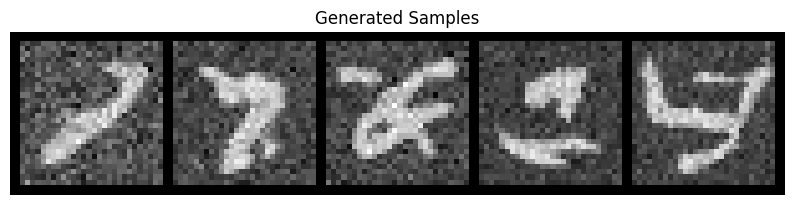

  Step 600/750, Loss: 0.0595
  Step 700/750, Loss: 0.0598

Training - Epoch 27 average loss: 0.0560
Running validation...
Validation - Epoch 27 average loss: 0.0560
Learning rate: 0.000500

Generating samples for visual progress check...


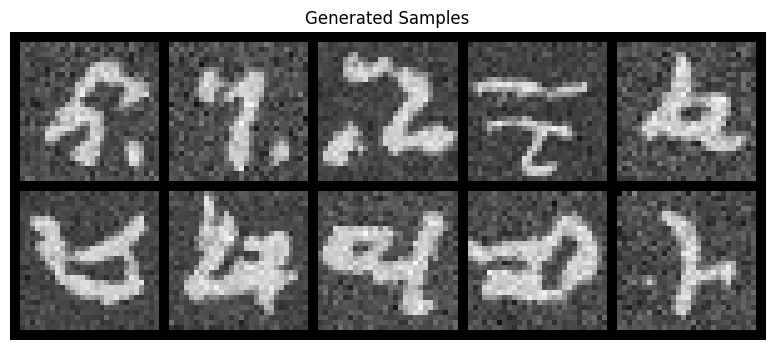

Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0560)

Epoch 28/30
--------------------
  Step 0/750, Loss: 0.0552
  Step 100/750, Loss: 0.0569
  Step 200/750, Loss: 0.0661
  Step 300/750, Loss: 0.0640
  Step 400/750, Loss: 0.0550
  Step 500/750, Loss: 0.0565
  Generating samples...


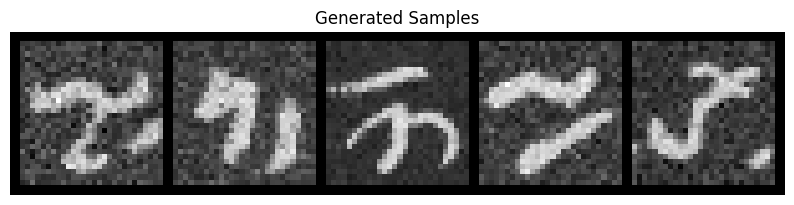

  Step 600/750, Loss: 0.0542
  Step 700/750, Loss: 0.0459

Training - Epoch 28 average loss: 0.0559
Running validation...
Validation - Epoch 28 average loss: 0.0552
Learning rate: 0.000500
Created backup at best_diffusion_model.pt.backup
Model successfully saved to best_diffusion_model.pt
✓ New best model saved! (Val Loss: 0.0552)

Epoch 29/30
--------------------
  Step 0/750, Loss: 0.0519
  Step 100/750, Loss: 0.0559
  Step 200/750, Loss: 0.0581
  Step 300/750, Loss: 0.0587
  Step 400/750, Loss: 0.0603
  Step 500/750, Loss: 0.0541
  Generating samples...


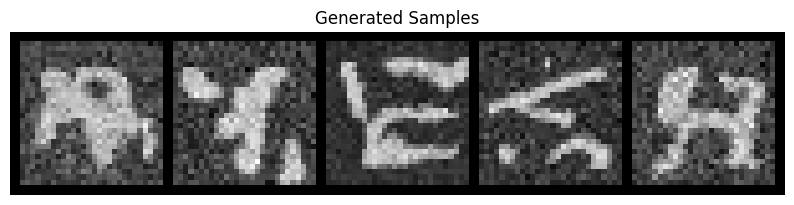

  Step 600/750, Loss: 0.0589
  Step 700/750, Loss: 0.0519

Training - Epoch 29 average loss: 0.0558
Running validation...
Validation - Epoch 29 average loss: 0.0558
Learning rate: 0.000500

Generating samples for visual progress check...


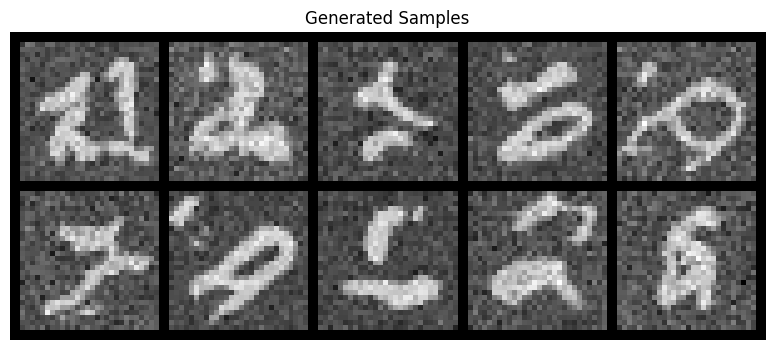

No improvement for 1/10 epochs

Epoch 30/30
--------------------
  Step 0/750, Loss: 0.0590
  Step 100/750, Loss: 0.0574
  Step 200/750, Loss: 0.0613
  Step 300/750, Loss: 0.0592
  Step 400/750, Loss: 0.0545
  Step 500/750, Loss: 0.0496
  Generating samples...


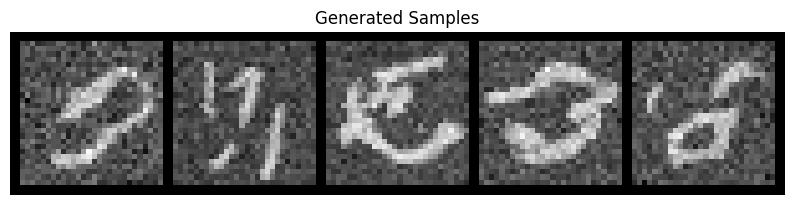

  Step 600/750, Loss: 0.0541
  Step 700/750, Loss: 0.0585

Training - Epoch 30 average loss: 0.0558
Running validation...
Validation - Epoch 30 average loss: 0.0559
Learning rate: 0.000500

Generating samples for visual progress check...


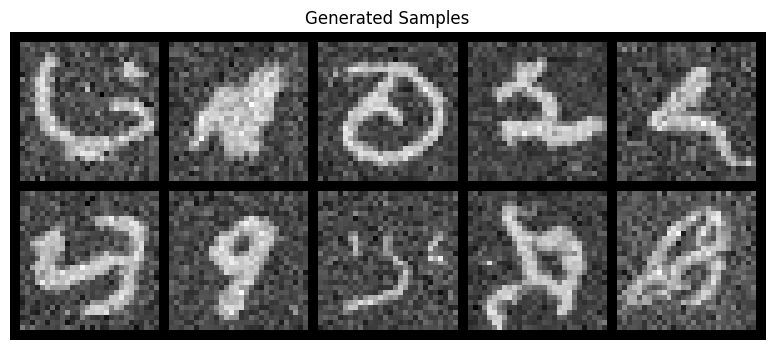

No improvement for 2/10 epochs


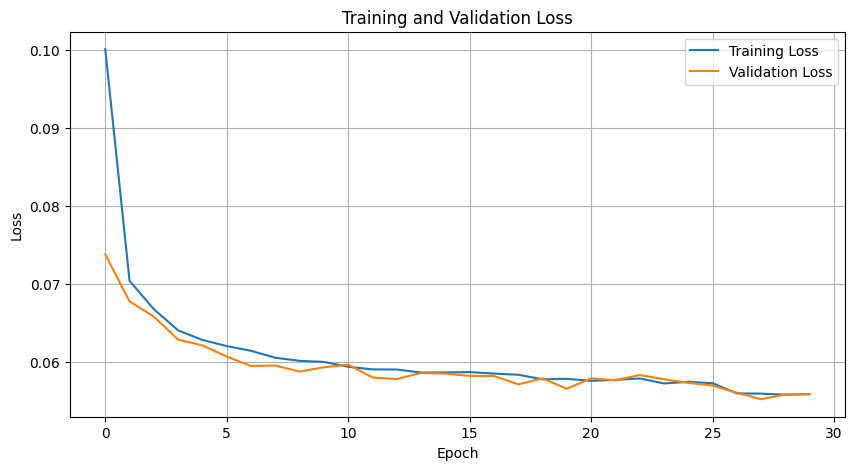


TRAINING COMPLETE
Best validation loss: 0.0552
Generating final samples...


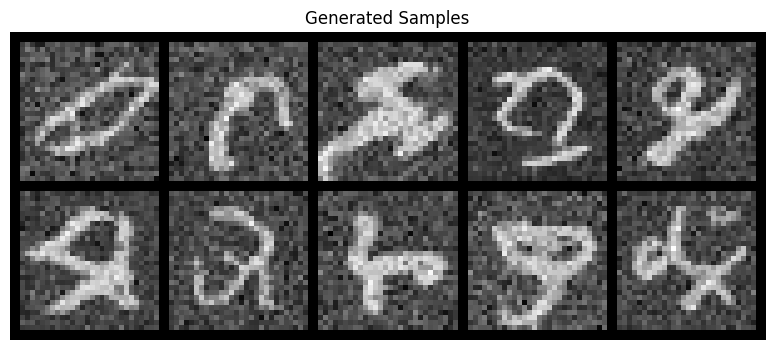

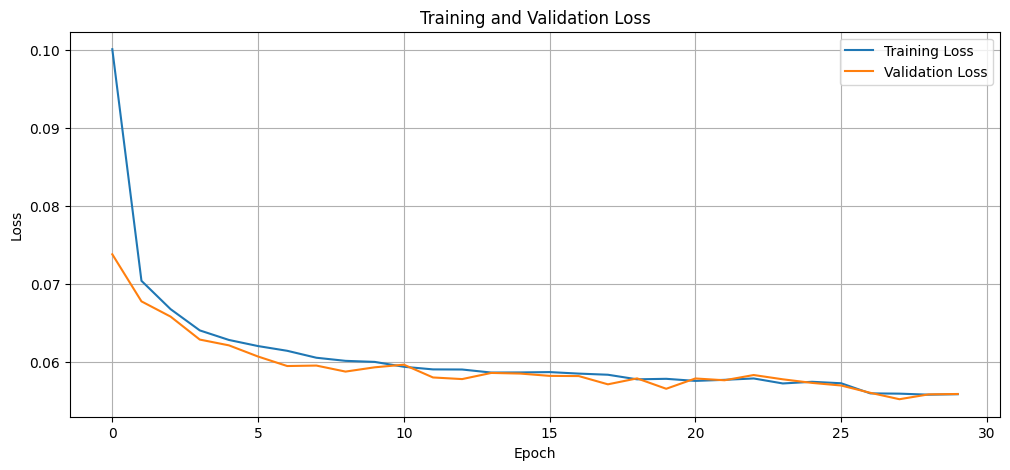

In [22]:
# Define helper functions needed for training and evaluation

def train_step(x, c):
    """
    Performs a single training step for the diffusion model.

    This function:
    1. Prepares class conditioning
    2. Samples random timesteps for each image
    3. Adds corresponding noise to the images
    4. Asks the model to predict the noise
    5. Calculates the loss between predicted and actual noise

    Args:
        x (torch.Tensor): Batch of clean images [batch_size, channels, height, width]
        c (torch.Tensor): Batch of class labels [batch_size]

    Returns:
        torch.Tensor: Mean squared error loss value
    """
    # Convert number labels to one-hot encoding for class conditioning
    c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)

    # Create conditioning mask (all ones for standard training)
    c_mask = torch.ones_like(c.unsqueeze(-1)).float().to(device)

    # Pick random timesteps for each image in the batch
    t = torch.randint(0, n_steps, (x.shape[0],)).to(device)

    # Add noise to images according to the forward diffusion process
    x_t, noise = add_noise(x, t)

    # The model tries to predict the exact noise that was added
    predicted_noise = model(x_t, t, c_one_hot, c_mask)

    # Calculate loss: MSE between predicted and actual noise
    loss = F.mse_loss(predicted_noise, noise)
    return loss


# Implementation of the main training loop
# Training configuration
early_stopping_patience = 10  # Number of epochs without improvement before stopping
gradient_clip_value = 1.0     # Maximum gradient norm for stability
display_frequency = 100       # How often to show progress (in steps)
generate_frequency = 500      # How often to generate samples (in steps)

# Progress tracking variables
best_loss = float('inf')
train_losses = []
val_losses = []
no_improve_epochs = 0

# Training loop
print("\n" + "="*50)
print("STARTING TRAINING")
print("="*50)
model.train()

# Wrap the training loop in a try-except block for better error handling:
# Your code for the training loop
# Hint: Use a try-except block for better error handling
# Process each epoch and each batch, with validation after each epoch

try:
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        print("-" * 20)

        # Training phase
        model.train()
        epoch_losses = []

        # Process each batch
        for step, (images, labels) in enumerate(train_dataloader):
            images = images.to(device)
            labels = labels.to(device)

            # Training step
            optimizer.zero_grad()
            loss = train_step(images, labels)
            loss.backward()

            # Add gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=gradient_clip_value)

            optimizer.step()
            epoch_losses.append(loss.item())

            # Show progress at regular intervals
            if step % display_frequency == 0:
                print(f"  Step {step}/{len(train_dataloader)}, Loss: {loss.item():.4f}")

                # Generate samples less frequently to save time
                if step % generate_frequency == 0 and step > 0:
                    print("  Generating samples...")
                    generate_samples(model, n_samples=5)

        # End of epoch - calculate average training loss
        avg_train_loss = sum(epoch_losses) / len(epoch_losses)
        train_losses.append(avg_train_loss)
        print(f"\nTraining - Epoch {epoch+1} average loss: {avg_train_loss:.4f}")

        # Validation phase
        model.eval()
        val_epoch_losses = []
        print("Running validation...")

        with torch.no_grad():  # Disable gradients for validation
            for val_images, val_labels in val_dataloader:
                val_images = val_images.to(device)
                val_labels = val_labels.to(device)

                # Calculate validation loss
                val_loss = train_step(val_images, val_labels)
                val_epoch_losses.append(val_loss.item())

        # Calculate average validation loss
        avg_val_loss = sum(val_epoch_losses) / len(val_epoch_losses)
        val_losses.append(avg_val_loss)
        print(f"Validation - Epoch {epoch+1} average loss: {avg_val_loss:.4f}")

        # Learning rate scheduling based on validation loss
        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Learning rate: {current_lr:.6f}")

        # Generate samples at the end of each epoch
        if epoch % 2 == 0 or epoch == EPOCHS - 1:
            print("\nGenerating samples for visual progress check...")
            generate_samples(model, n_samples=10)

        # Save best model based on validation loss
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            # Use safe_save_model instead of just saving state_dict
            safe_save_model(model, 'best_diffusion_model.pt', optimizer, epoch, best_loss)
            print(f"✓ New best model saved! (Val Loss: {best_loss:.4f})")
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            print(f"No improvement for {no_improve_epochs}/{early_stopping_patience} epochs")

        # Early stopping
        if no_improve_epochs >= early_stopping_patience:
            print("\nEarly stopping triggered! No improvement in validation loss.")
            break

        # Plot loss curves every few epochs
        if epoch % 5 == 0 or epoch == EPOCHS - 1:
            plt.figure(figsize=(10, 5))
            plt.plot(train_losses, label='Training Loss')
            plt.plot(val_losses, label='Validation Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.title('Training and Validation Loss')
            plt.legend()
            plt.grid(True)
            plt.show()


except KeyboardInterrupt:
    print("\nTraining interrupted by user.")
except Exception as e:
    print(f"\nTraining error: {e}")
    import traceback
    traceback.print_exc()

# Final wrap-up
print("\n" + "="*50)
print("TRAINING COMPLETE")
print("="*50)
print(f"Best validation loss: {best_loss:.4f}")

# Generate final samples
print("Generating final samples...")
generate_samples(model, n_samples=10)

# Display final loss curves
plt.figure(figsize=(12, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Clean up memory
torch.cuda.empty_cache()

## Step 6: Generating New Images

Now that our model is trained, let's generate some new images! We can:
1. Generate specific numbers
2. Generate multiple versions of each number
3. See how the generation process works step by step

Generating 4 versions of number 0...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 1...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 2...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 3...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 4...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 

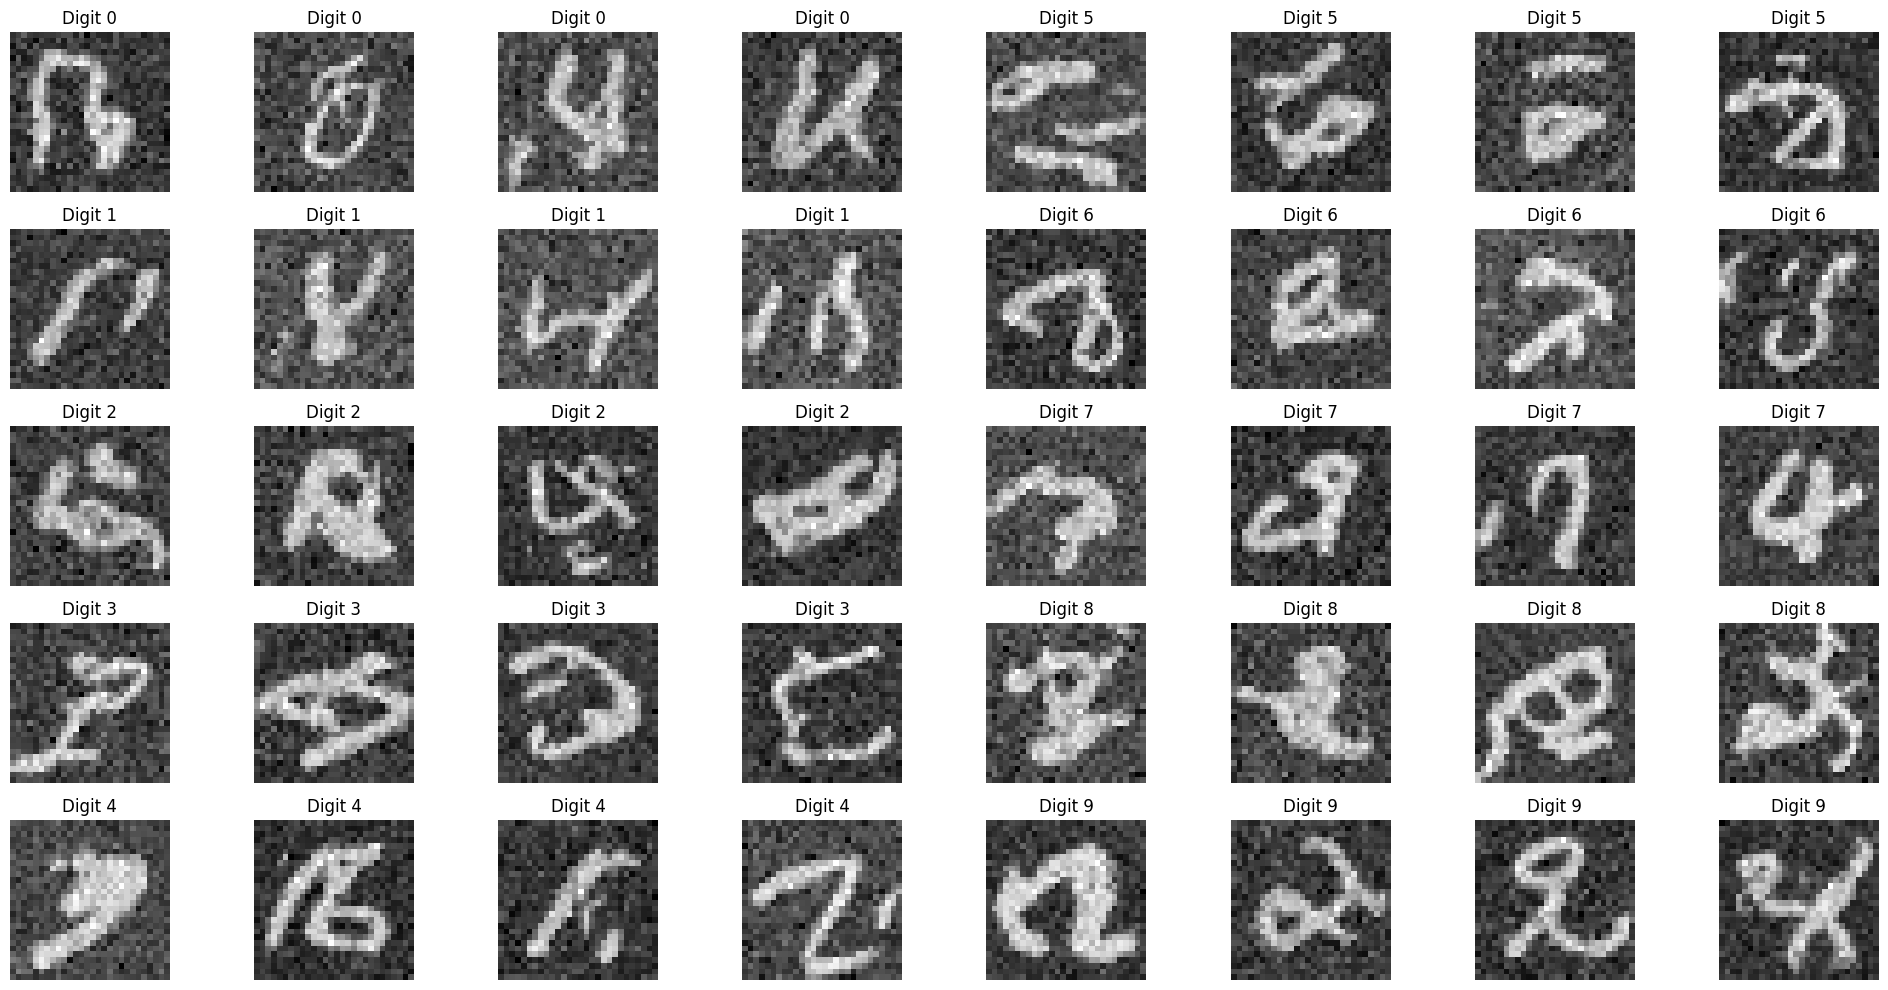


STUDENT ACTIVITY: Generating numbers with different noise seeds
Generating 10 versions of number 7...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


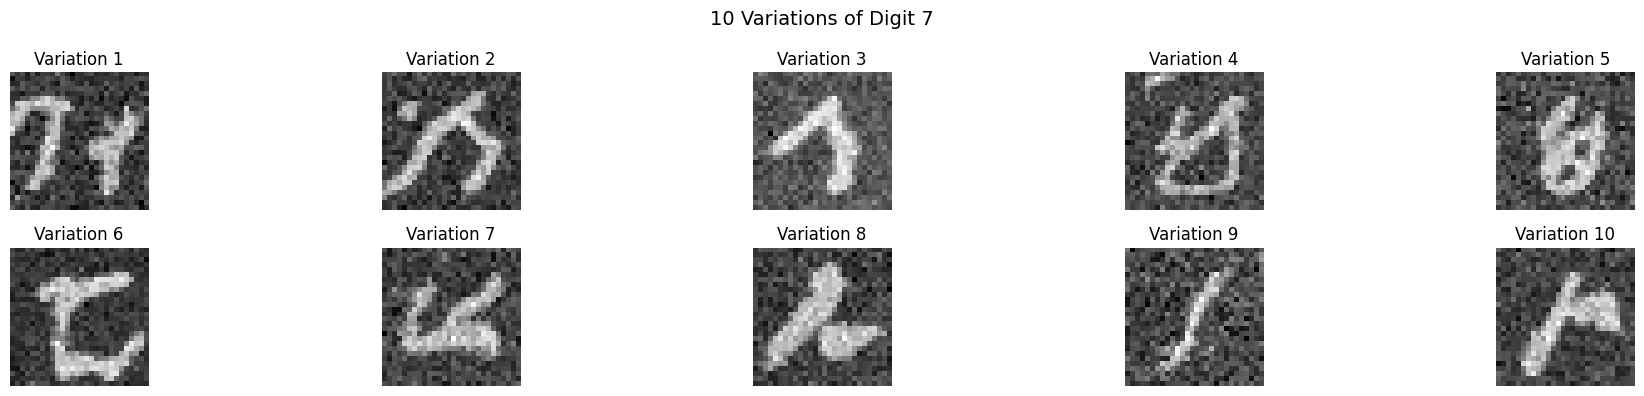

In [23]:
def generate_number(model, number, n_samples=4):
    """
    Generate multiple versions of a specific number using the diffusion model.

    Args:
        model (nn.Module): The trained diffusion model
        number (int): The digit to generate (0-9)
        n_samples (int): Number of variations to generate

    Returns:
        torch.Tensor: Generated images of shape [n_samples, IMG_CH, IMG_SIZE, IMG_SIZE]
    """
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # No need for gradients during generation
        # Start with random noise
        samples = torch.randn(n_samples, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

        # Set up the number we want to generate
        c = torch.full((n_samples,), number).to(device)
        c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
        # Correctly sized conditioning mask
        c_mask = torch.ones_like(c.unsqueeze(-1)).float().to(device)

        # Display progress information
        print(f"Generating {n_samples} versions of number {number}...")

        # Remove noise step by step
        for t in range(n_steps-1, -1, -1):
            t_batch = torch.full((n_samples,), t).to(device)
            samples = remove_noise(samples, t_batch, model, c_one_hot, c_mask)

            # Optional: Display occasional progress updates
            if t % (n_steps // 5) == 0:
                print(f"  Denoising step {n_steps-1-t}/{n_steps-1} completed")

        return samples

# Generate 4 versions of each number
plt.figure(figsize=(20, 10))
for i in range(10):
    # Generate samples for current digit
    samples = generate_number(model, i, n_samples=4)

    # Display each sample
    for j in range(4):
        # Use 2 rows, 10 digits per row, 4 samples per digit
        # i//5 determines the row (0 or 1)
        # i%5 determines the position in the row (0-4)
        # j is the sample index within each digit (0-3)
        plt.subplot(5, 8, (i%5)*8 + (i//5)*4 + j + 1)

        # Display the image correctly based on channel configuration
        if IMG_CH == 1:  # Grayscale
            plt.imshow(samples[j][0].cpu(), cmap='gray')
        else:  # Color image
            img = samples[j].permute(1, 2, 0).cpu()
            # Rescale from [-1, 1] to [0, 1] if needed
            if img.min() < 0:
                img = (img + 1) / 2
            plt.imshow(img)

        plt.title(f'Digit {i}')
        plt.axis('off')

plt.tight_layout()
plt.show()

# STUDENT ACTIVITY: Try generating the same digit with different noise seeds
# This shows the variety of styles the model can produce
print("\nSTUDENT ACTIVITY: Generating numbers with different noise seeds")

# Helper function to generate with seed
def generate_with_seed(number, seed_value=42, n_samples=10):
    torch.manual_seed(seed_value)
    return generate_number(model, number, n_samples)

# Pick a image and show many variations
# Hint select a image e.g. dog  # Change this to any other in the dataset of subset you chose
# Hint 2 use variations = generate_with_seed
# Hint 3 use plt.figure and plt.imshow to display the variations

# Generate 10 variations of digit 7 with a fixed seed
chosen_digit = 7  # Pick a digit to explore
variations = generate_with_seed(chosen_digit, seed_value=42, n_samples=10)

plt.figure(figsize=(20, 4))
for idx in range(10):
    plt.subplot(2, 5, idx + 1)
    if IMG_CH == 1:
        plt.imshow(variations[idx][0].cpu(), cmap='gray')
    else:
        img = variations[idx].permute(1, 2, 0).cpu()
        if img.min() < 0:
            img = (img + 1) / 2
        plt.imshow(img)
    plt.title(f'Variation {idx+1}')
    plt.axis('off')
plt.suptitle(f'10 Variations of Digit {chosen_digit}', fontsize=14)
plt.tight_layout()
plt.show()

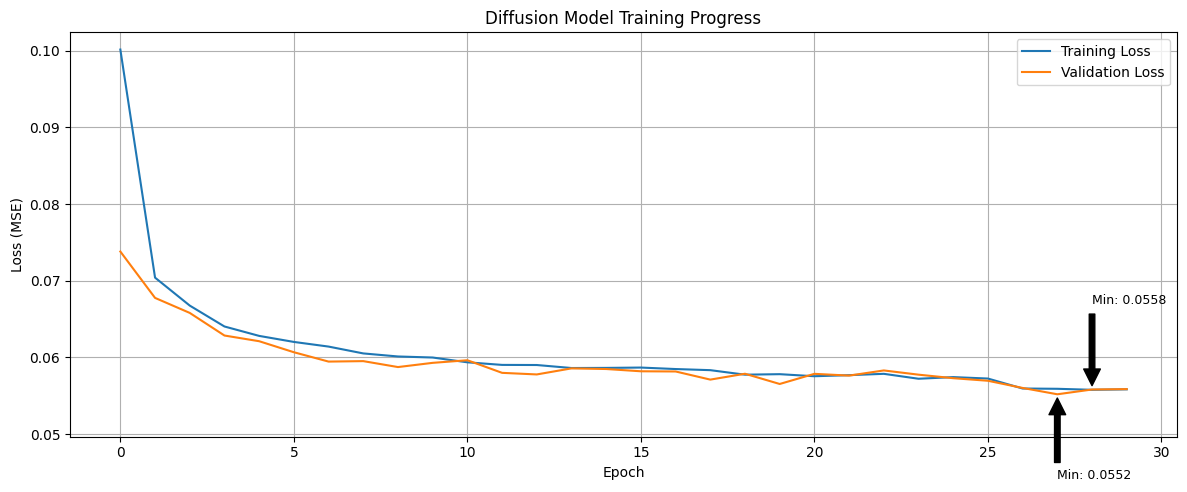


Training Statistics:
------------------------------
Starting training loss:    0.1001
Final training loss:       0.0558
Best training loss:        0.0558
Training loss improvement: 44.3%

Validation Statistics:
------------------------------
Starting validation loss: 0.0738
Final validation loss:    0.0559
Best validation loss:     0.0552


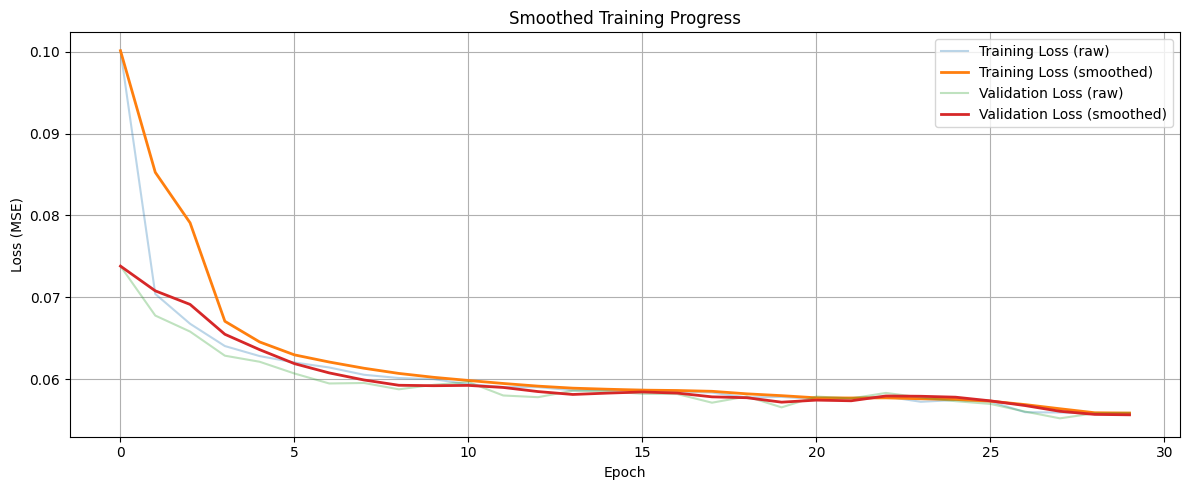

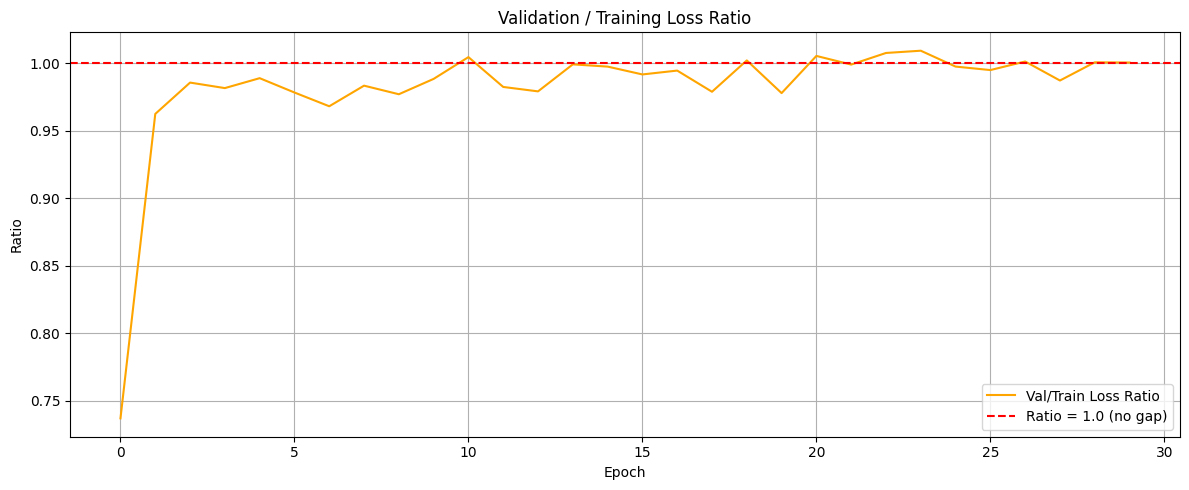

Final val/train ratio: 1.001
Ratio looks reasonable, no major overfitting


In [24]:
# Plot training progress
plt.figure(figsize=(12, 5))

# Plot training and validation losses for comparison
plt.plot(train_losses, label='Training Loss')
if len(val_losses) > 0:  # Only plot validation if it exists
    plt.plot(val_losses, label='Validation Loss')

# Improve the plot with better labels and styling
plt.title('Diffusion Model Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Add annotations for key points only if data is available
if train_losses:
    min_train_idx = train_losses.index(min(train_losses))
    plt.annotate(f'Min: {min(train_losses):.4f}',
                 xy=(min_train_idx, min(train_losses)),
                 xytext=(min_train_idx, min(train_losses)*1.2),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=9)

# Add validation min point if available
if val_losses:
    min_val_idx = val_losses.index(min(val_losses))
    plt.annotate(f'Min: {min(val_losses):.4f}',
                xy=(min_val_idx, min(val_losses)),
                xytext=(min_val_idx, min(val_losses)*0.8),
                arrowprops=dict(facecolor='black', shrink=0.05),
                fontsize=9)

# Set y-axis to start from 0 or slightly lower than min value, only if data is available
if train_losses or val_losses:
    all_losses = []
    if train_losses: all_losses.extend(train_losses)
    if val_losses: all_losses.extend(val_losses)
    if all_losses:
        plt.ylim(bottom=max(0, min(all_losses) * 0.9))

plt.tight_layout()
plt.show()

# Add statistics summary for students to analyze
print("\nTraining Statistics:")
print("-" * 30)
if train_losses:
    print(f"Starting training loss:    {train_losses[0]:.4f}")
    print(f"Final training loss:       {train_losses[-1]:.4f}")
    print(f"Best training loss:        {min(train_losses):.4f}")
    print(f"Training loss improvement: {((train_losses[0] - min(train_losses)) / train_losses[0] * 100):.1f}%")

if val_losses:
    print("\nValidation Statistics:")
    print("-" * 30)
    print(f"Starting validation loss: {val_losses[0]:.4f}")
    print(f"Final validation loss:    {val_losses[-1]:.4f}")
    print(f"Best validation loss:     {min(val_losses):.4f}")

# STUDENT EXERCISE:
# 1. Try modifying this plot to show a smoothed version of the losses
# 2. Create a second plot showing the ratio of validation to training loss
#    (which can indicate overfitting when the ratio increases)

# 1. Smoothed version of the losses
def smooth_losses(losses, window=3):
    smoothed = []
    for i in range(len(losses)):
        start = max(0, i - window + 1)
        smoothed.append(sum(losses[start:i+1]) / len(losses[start:i+1]))
    return smoothed

if train_losses and len(train_losses) > 1:
    plt.figure(figsize=(12, 5))
    plt.plot(train_losses, alpha=0.3, label='Training Loss (raw)')
    plt.plot(smooth_losses(train_losses, window=3), label='Training Loss (smoothed)', linewidth=2)
    if val_losses and len(val_losses) > 1:
        plt.plot(val_losses, alpha=0.3, label='Validation Loss (raw)')
        plt.plot(smooth_losses(val_losses, window=3), label='Validation Loss (smoothed)', linewidth=2)
    plt.title('Smoothed Training Progress')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 2. Ratio of validation to training loss
if train_losses and val_losses and len(train_losses) > 1 and len(val_losses) > 1:
    ratio = [v / t if t > 0 else 0 for v, t in zip(val_losses, train_losses)]
    plt.figure(figsize=(12, 5))
    plt.plot(ratio, label='Val/Train Loss Ratio', color='orange')
    plt.axhline(y=1.0, color='red', linestyle='--', label='Ratio = 1.0 (no gap)')
    plt.title('Validation / Training Loss Ratio')
    plt.xlabel('Epoch')
    plt.ylabel('Ratio')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print(f"Final val/train ratio: {ratio[-1]:.3f}")
    if ratio[-1] > 1.2:
        print("Ratio above 1.2 suggests some overfitting")
    else:
        print("Ratio looks reasonable, no major overfitting")

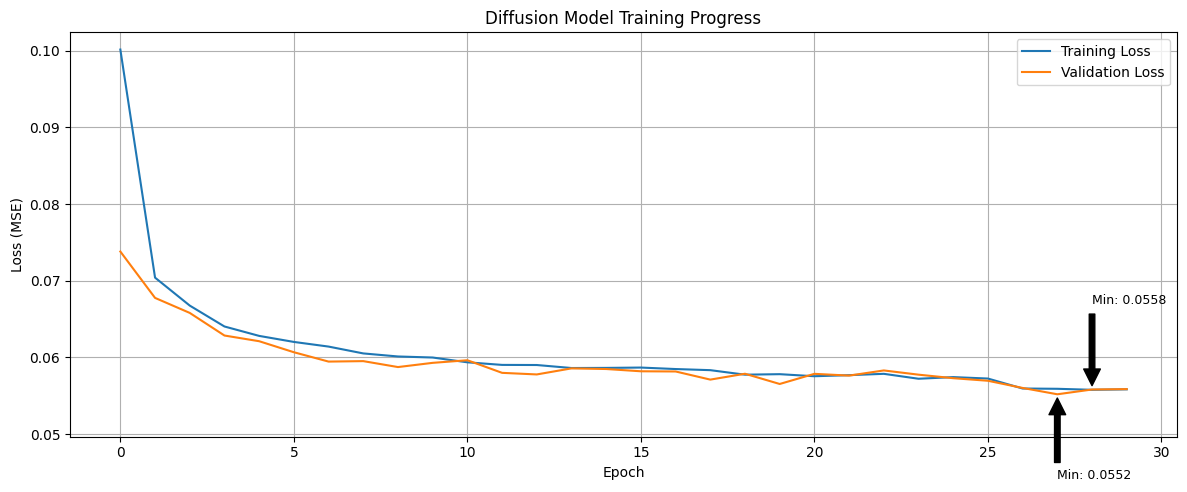


Training Statistics:
------------------------------
Starting training loss:    0.1001
Final training loss:       0.0558
Best training loss:        0.0558
Training loss improvement: 44.3%

Validation Statistics:
------------------------------
Starting validation loss: 0.0738
Final validation loss:    0.0559
Best validation loss:     0.0552


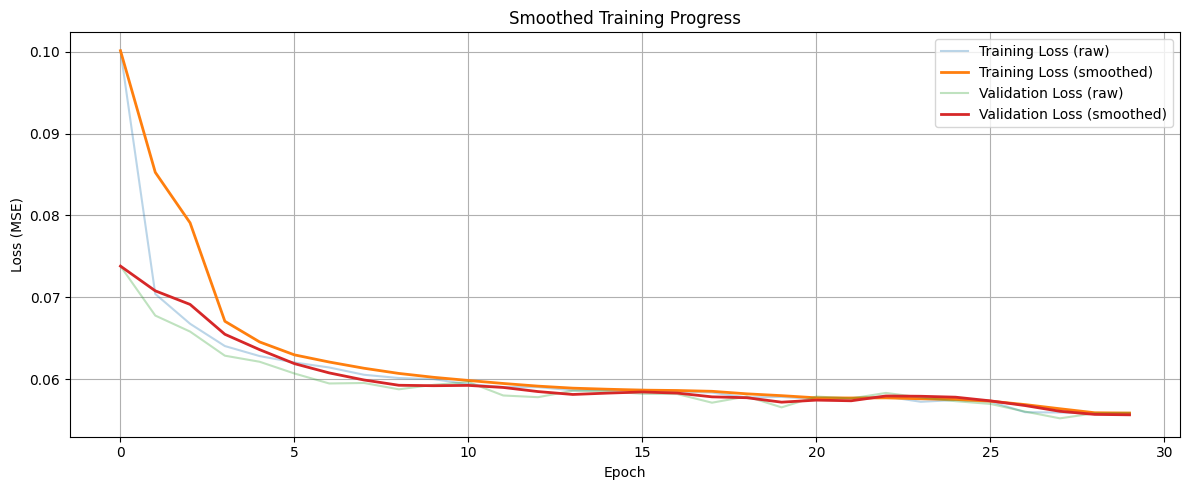

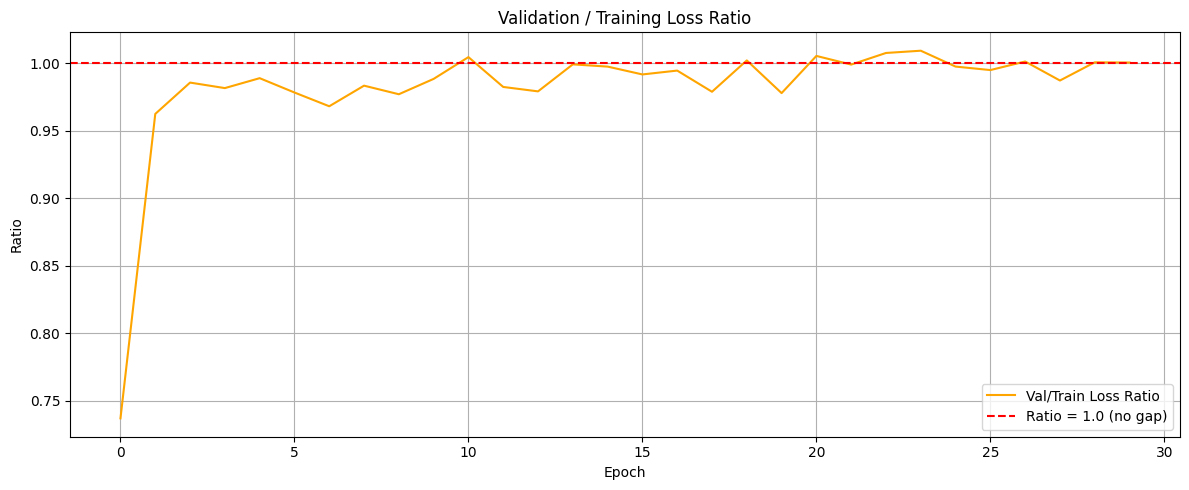

Final val/train ratio: 1.001
Ratio looks reasonable, no major overfitting


In [25]:
# Plot training progress
plt.figure(figsize=(12, 5))

# Plot training and validation losses for comparison
plt.plot(train_losses, label='Training Loss')
if len(val_losses) > 0:  # Only plot validation if it exists
    plt.plot(val_losses, label='Validation Loss')

# Improve the plot with better labels and styling
plt.title('Diffusion Model Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Add annotations for key points only if data is available
if train_losses:
    min_train_idx = train_losses.index(min(train_losses))
    plt.annotate(f'Min: {min(train_losses):.4f}',
                 xy=(min_train_idx, min(train_losses)),
                 xytext=(min_train_idx, min(train_losses)*1.2),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=9)

# Add validation min point if available
if val_losses:
    min_val_idx = val_losses.index(min(val_losses))
    plt.annotate(f'Min: {min(val_losses):.4f}',
                xy=(min_val_idx, min(val_losses)),
                xytext=(min_val_idx, min(val_losses)*0.8),
                arrowprops=dict(facecolor='black', shrink=0.05),
                fontsize=9)

# Set y-axis to start from 0 or slightly lower than min value, only if data is available
if train_losses or val_losses:
    all_losses = []
    if train_losses: all_losses.extend(train_losses)
    if val_losses: all_losses.extend(val_losses)
    if all_losses:
        plt.ylim(bottom=max(0, min(all_losses) * 0.9))

plt.tight_layout()
plt.show()

# Add statistics summary for students to analyze
print("\nTraining Statistics:")
print("-" * 30)
if train_losses:
    print(f"Starting training loss:    {train_losses[0]:.4f}")
    print(f"Final training loss:       {train_losses[-1]:.4f}")
    print(f"Best training loss:        {min(train_losses):.4f}")
    print(f"Training loss improvement: {((train_losses[0] - min(train_losses)) / train_losses[0] * 100):.1f}%")

if val_losses:
    print("\nValidation Statistics:")
    print("-" * 30)
    print(f"Starting validation loss: {val_losses[0]:.4f}")
    print(f"Final validation loss:    {val_losses[-1]:.4f}")
    print(f"Best validation loss:     {min(val_losses):.4f}")

# STUDENT EXERCISE:
# 1. Try modifying this plot to show a smoothed version of the losses
# 2. Create a second plot showing the ratio of validation to training loss
#    (which can indicate overfitting when the ratio increases)

# 1. Smoothed version of the losses
def smooth_losses(losses, window=3):
    smoothed = []
    for i in range(len(losses)):
        start = max(0, i - window + 1)
        smoothed.append(sum(losses[start:i+1]) / len(losses[start:i+1]))
    return smoothed

if train_losses and len(train_losses) > 1:
    plt.figure(figsize=(12, 5))
    plt.plot(train_losses, alpha=0.3, label='Training Loss (raw)')
    plt.plot(smooth_losses(train_losses, window=3), label='Training Loss (smoothed)', linewidth=2)
    if val_losses and len(val_losses) > 1:
        plt.plot(val_losses, alpha=0.3, label='Validation Loss (raw)')
        plt.plot(smooth_losses(val_losses, window=3), label='Validation Loss (smoothed)', linewidth=2)
    plt.title('Smoothed Training Progress')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 2. Ratio of validation to training loss
if train_losses and val_losses and len(train_losses) > 1 and len(val_losses) > 1:
    ratio = [v / t if t > 0 else 0 for v, t in zip(val_losses, train_losses)]
    plt.figure(figsize=(12, 5))
    plt.plot(ratio, label='Val/Train Loss Ratio', color='orange')
    plt.axhline(y=1.0, color='red', linestyle='--', label='Ratio = 1.0 (no gap)')
    plt.title('Validation / Training Loss Ratio')
    plt.xlabel('Epoch')
    plt.ylabel('Ratio')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print(f"Final val/train ratio: {ratio[-1]:.3f}")
    if ratio[-1] > 1.2:
        print("Ratio above 1.2 suggests some overfitting")
    else:
        print("Ratio looks reasonable, no major overfitting")


## Step 6: Generating New Images

Now that our model is trained, let's generate some new images! We can:
1. Generate specific numbers
2. Generate multiple versions of each number
3. See how the generation process works step by step

Generating 4 versions of number 0...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 1...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 2...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 3...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 4...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 

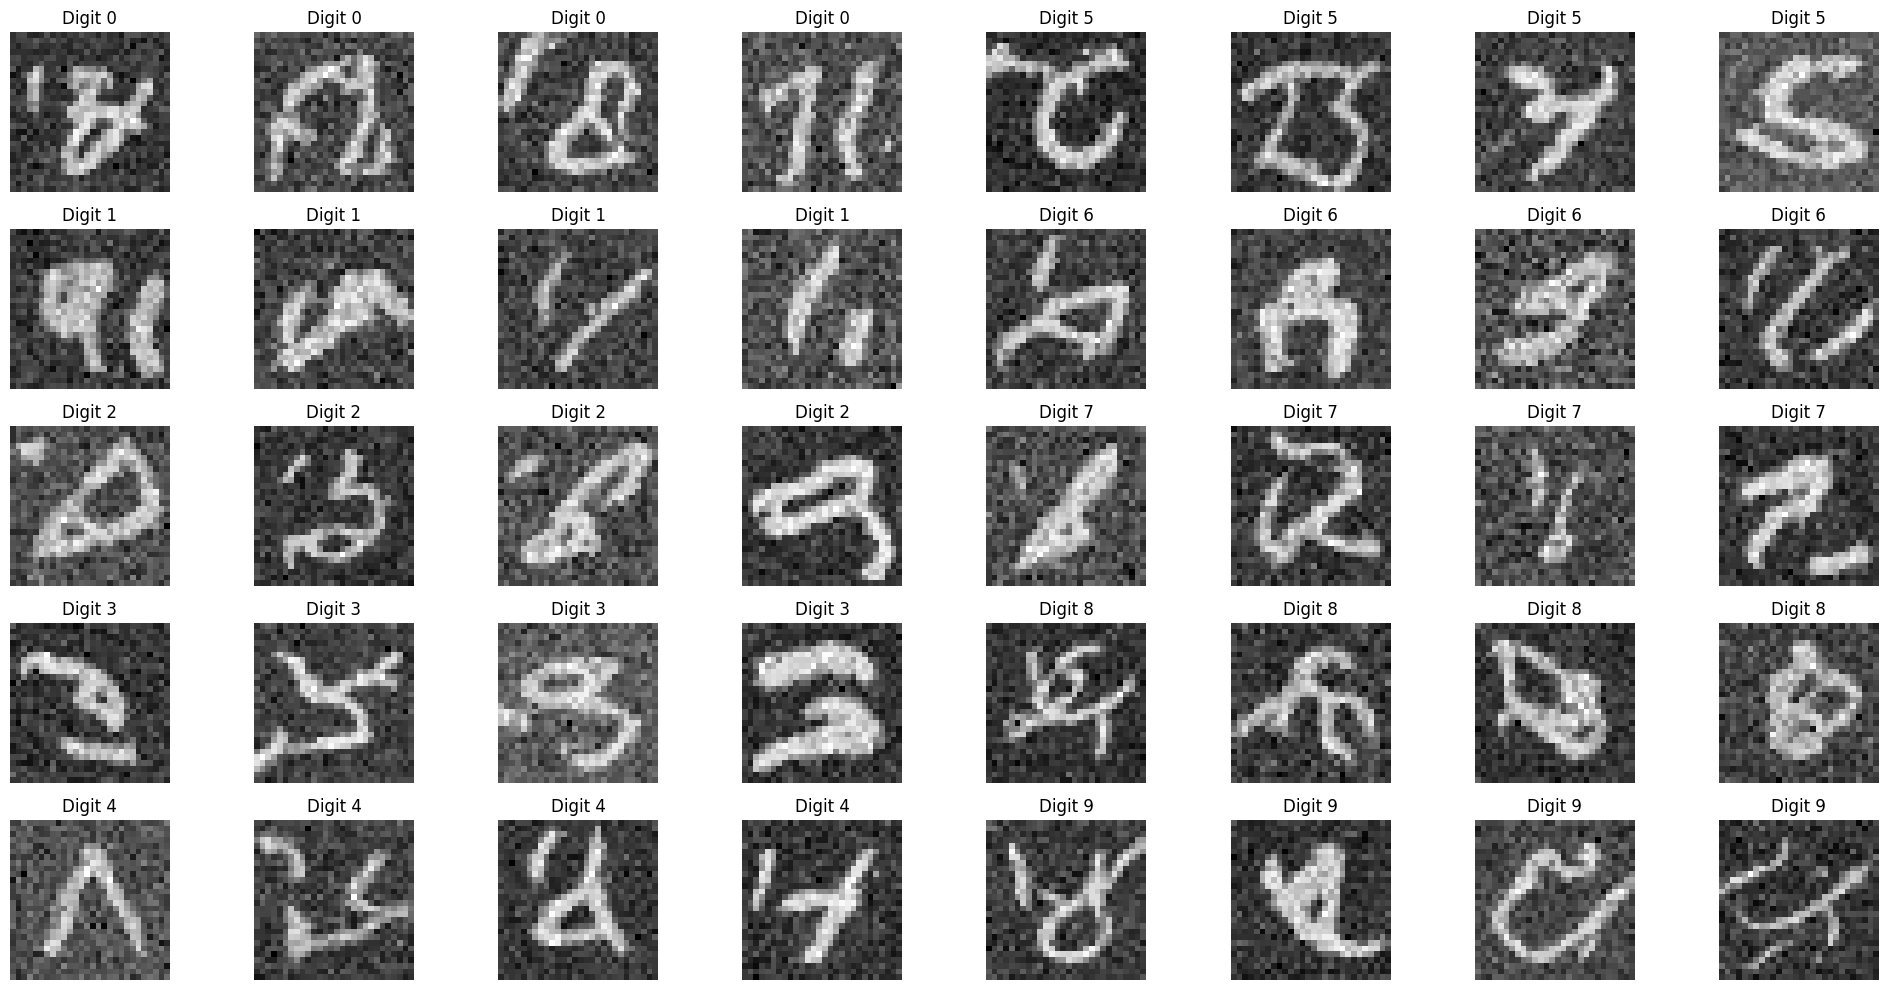


STUDENT ACTIVITY: Generating numbers with different noise seeds
Generating 10 versions of number 7...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


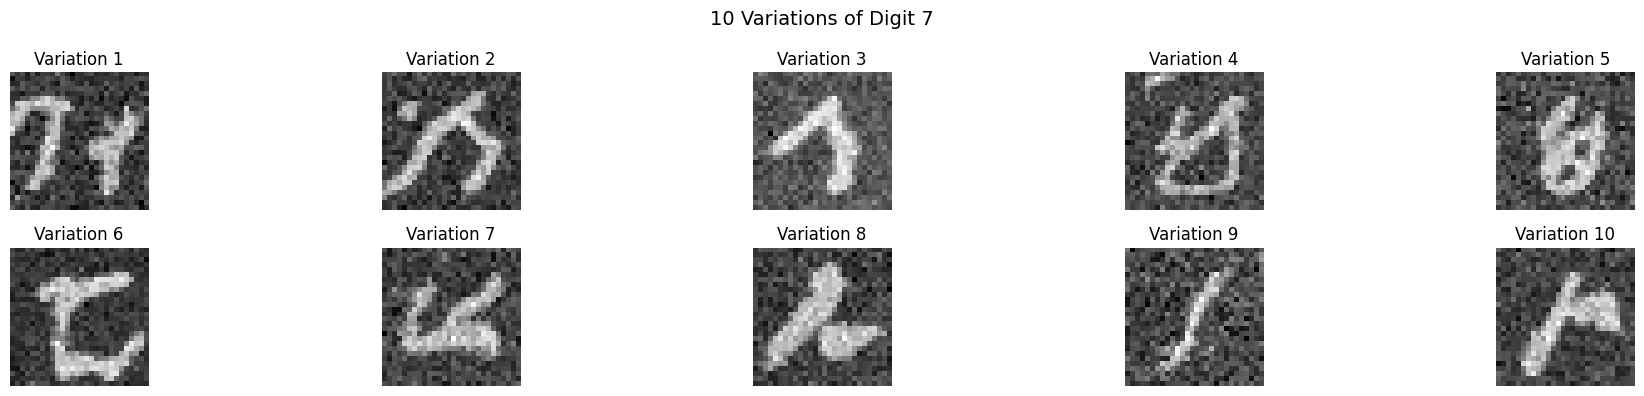

In [26]:
def generate_number(model, number, n_samples=4):
    """
    Generate multiple versions of a specific number using the diffusion model.

    Args:
        model (nn.Module): The trained diffusion model
        number (int): The digit to generate (0-9)
        n_samples (int): Number of variations to generate

    Returns:
        torch.Tensor: Generated images of shape [n_samples, IMG_CH, IMG_SIZE, IMG_SIZE]
    """
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # No need for gradients during generation
        # Start with random noise
        samples = torch.randn(n_samples, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

        # Set up the number we want to generate
        c = torch.full((n_samples,), number).to(device)
        c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
        # Correctly sized conditioning mask
        c_mask = torch.ones_like(c.unsqueeze(-1)).float().to(device)

        # Display progress information
        print(f"Generating {n_samples} versions of number {number}...")

        # Remove noise step by step
        for t in range(n_steps-1, -1, -1):
            t_batch = torch.full((n_samples,), t).to(device)
            samples = remove_noise(samples, t_batch, model, c_one_hot, c_mask)

            # Optional: Display occasional progress updates
            if t % (n_steps // 5) == 0:
                print(f"  Denoising step {n_steps-1-t}/{n_steps-1} completed")

        return samples

# Generate 4 versions of each number
plt.figure(figsize=(20, 10))
for i in range(10):
    # Generate samples for current digit
    samples = generate_number(model, i, n_samples=4)

    # Display each sample
    for j in range(4):
        # Use 2 rows, 10 digits per row, 4 samples per digit
        # i//5 determines the row (0 or 1)
        # i%5 determines the position in the row (0-4)
        # j is the sample index within each digit (0-3)
        plt.subplot(5, 8, (i%5)*8 + (i//5)*4 + j + 1)

        # Display the image correctly based on channel configuration
        if IMG_CH == 1:  # Grayscale
            plt.imshow(samples[j][0].cpu(), cmap='gray')
        else:  # Color image
            img = samples[j].permute(1, 2, 0).cpu()
            # Rescale from [-1, 1] to [0, 1] if needed
            if img.min() < 0:
                img = (img + 1) / 2
            plt.imshow(img)

        plt.title(f'Digit {i}')
        plt.axis('off')

plt.tight_layout()
plt.show()

# STUDENT ACTIVITY: Try generating the same digit with different noise seeds
# This shows the variety of styles the model can produce
print("\nSTUDENT ACTIVITY: Generating numbers with different noise seeds")

# Helper function to generate with seed
def generate_with_seed(number, seed_value=42, n_samples=10):
    torch.manual_seed(seed_value)
    return generate_number(model, number, n_samples)

# Pick a image and show many variations
# Hint select a image e.g. dog  # Change this to any other in the dataset of subset you chose
# Hint 2 use variations = generate_with_seed
# Hint 3 use plt.figure and plt.imshow to display the variations

# Generate 10 variations of digit 7 with a fixed seed
chosen_digit = 7  # Pick a digit to explore
variations = generate_with_seed(chosen_digit, seed_value=42, n_samples=10)

plt.figure(figsize=(20, 4))
for idx in range(10):
    plt.subplot(2, 5, idx + 1)
    if IMG_CH == 1:
        plt.imshow(variations[idx][0].cpu(), cmap='gray')
    else:
        img = variations[idx].permute(1, 2, 0).cpu()
        if img.min() < 0:
            img = (img + 1) / 2
        plt.imshow(img)
    plt.title(f'Variation {idx+1}')
    plt.axis('off')
plt.suptitle(f'10 Variations of Digit {chosen_digit}', fontsize=14)
plt.tight_layout()
plt.show()


## Step 7: Watching the Generation Process

Let's see how our model turns random noise into clear images, step by step. This helps us understand how the diffusion process works!


Generating number 0:


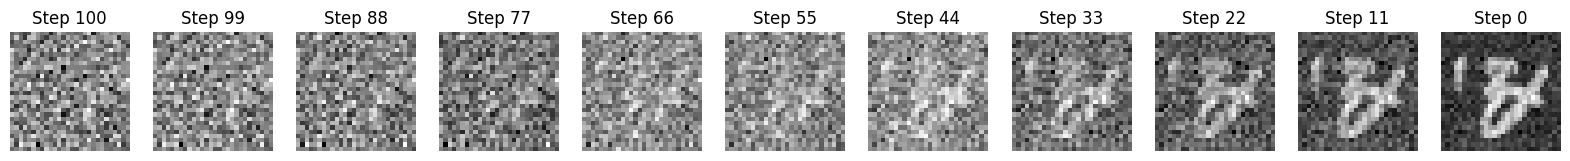


Generating number 3:


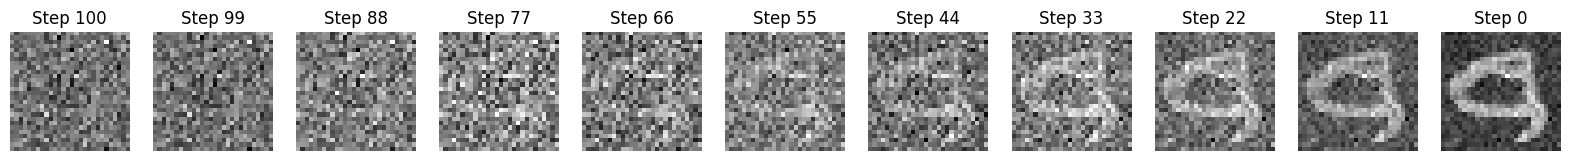


Generating number 7:


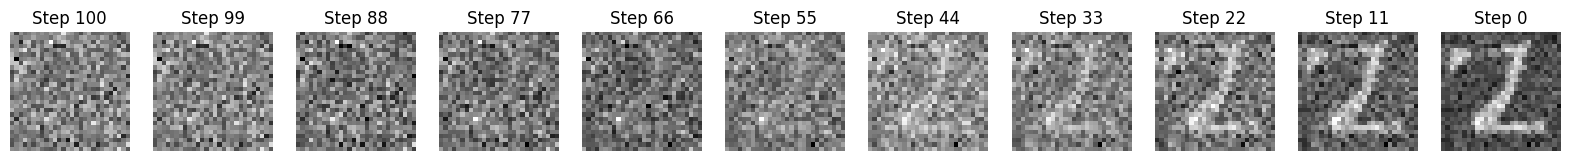

In [27]:
def visualize_generation_steps(model, number, n_preview_steps=10):
    """
    Show how an image evolves from noise to a clear number
    """
    model.eval()
    with torch.no_grad():
        # Start with random noise
        x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

        # Set up which number to generate
        c = torch.tensor([number]).to(device)
        c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
        c_mask = torch.ones_like(c_one_hot).to(device)

        # Calculate which steps to show
        steps_to_show = torch.linspace(n_steps-1, 0, n_preview_steps).long()

        # Store images for visualization
        images = []
        images.append(x[0].cpu())

        # Remove noise step by step
        for t in range(n_steps-1, -1, -1):
            t_batch = torch.full((1,), t).to(device)
            x = remove_noise(x, t_batch, model, c_one_hot, c_mask)

            if t in steps_to_show:
                images.append(x[0].cpu())

        # Show the progression
        plt.figure(figsize=(20, 3))
        for i, img in enumerate(images):
            plt.subplot(1, len(images), i+1)
            if IMG_CH == 1:
                plt.imshow(img[0], cmap='gray')
            else:
                img = img.permute(1, 2, 0)
                if img.min() < 0:
                    img = (img + 1) / 2
                plt.imshow(img)
            step = n_steps if i == 0 else steps_to_show[i-1]
            plt.title(f'Step {step}')
            plt.axis('off')
        plt.show()

# Show generation process for a few numbers
for number in [0, 3, 7]:
    print(f"\nGenerating number {number}:")
    visualize_generation_steps(model, number)

## Step 8: Adding CLIP Evaluation

[CLIP](https://openai.com/research/clip) is a powerful AI model that can understand both images and text. We'll use it to:
1. Evaluate how realistic our generated images are
2. Score how well they match their intended numbers
3. Help guide the generation process towards better quality

In [28]:
## Step 8: Adding CLIP Evaluation

# CLIP (Contrastive Language-Image Pre-training) is a powerful model by OpenAI that connects text and images.
# We'll use it to evaluate how recognizable our generated digits are by measuring how strongly
# the CLIP model associates our generated images with text descriptions like "an image of the digit 7".

# First, we need to install CLIP and its dependencies
print("Setting up CLIP (Contrastive Language-Image Pre-training) model...")

# Track installation status
clip_available = False

try:
    # Install dependencies first - these help CLIP process text and images
    print("Installing CLIP dependencies...")
    !pip install -q ftfy regex tqdm

    # Install CLIP from GitHub
    print("Installing CLIP from GitHub repository...")
    !pip install -q git+https://github.com/openai/CLIP.git

    # Import and verify CLIP is working
    print("Importing CLIP...")
    import clip

    # Test that CLIP is functioning
    models = clip.available_models()
    print(f"✓ CLIP installation successful! Available models: {models}")
    clip_available = True

except ImportError:
    print("❌ Error importing CLIP. Installation might have failed.")
    print("Try manually running: !pip install git+https://github.com/openai/CLIP.git")
    print("If you're in a Colab notebook, try restarting the runtime after installation.")

except Exception as e:
    print(f"❌ Error during CLIP setup: {e}")
    print("Some CLIP functionality may not work correctly.")

# Provide guidance based on installation result
if clip_available:
    print("\nCLIP is now available for evaluating your generated images!")
else:
    print("\nWARNING: CLIP installation failed. We'll skip the CLIP evaluation parts.")

# Import necessary libraries
import functools
import torch.nn.functional as F


Setting up CLIP (Contrastive Language-Image Pre-training) model...
Installing CLIP dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00
Installing CLIP from GitHub repository...
  Preparing metadata (setup.py) ... done
Importing CLIP...
✓ CLIP installation successful! Available models: ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']

CLIP is now available for evaluating your generated images!


 Below we are createing  a helper function to manage GPU memory when using CLIP. CLIP can be memory-intensive, so this will help prevent out-of-memory errors:

In [29]:
# Memory management decorator to prevent GPU OOM errors
def manage_gpu_memory(func):
    """
    Decorator that ensures proper GPU memory management.

    This wraps functions that might use large amounts of GPU memory,
    making sure memory is properly freed after function execution.
    """
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        if torch.cuda.is_available():
            # Clear cache before running function
            torch.cuda.empty_cache()
            try:
                return func(*args, **kwargs)
            finally:
                # Clear cache after running function regardless of success/failure
                torch.cuda.empty_cache()
        return func(*args, **kwargs)
    return wrapper

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 213MiB/s]


✓ Successfully loaded CLIP model: VisionTransformer

Generating and evaluating number 0...
Generating 4 versions of number 0...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


/tmp/ipykernel_4769/3182692817.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


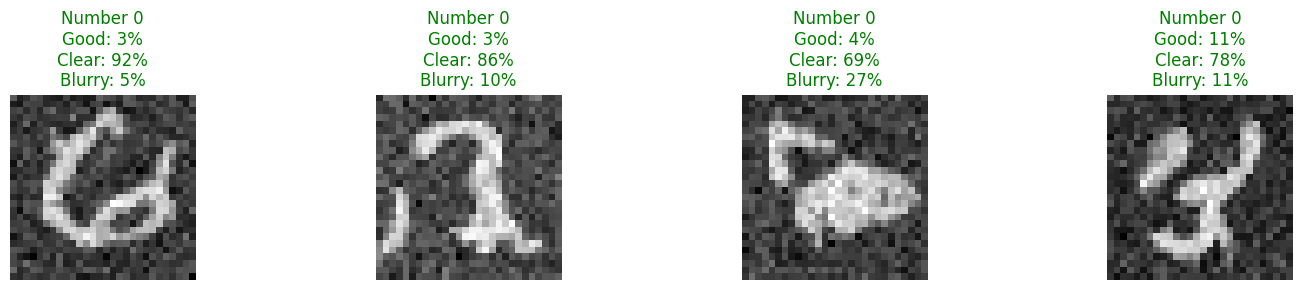


Generating and evaluating number 1...
Generating 4 versions of number 1...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


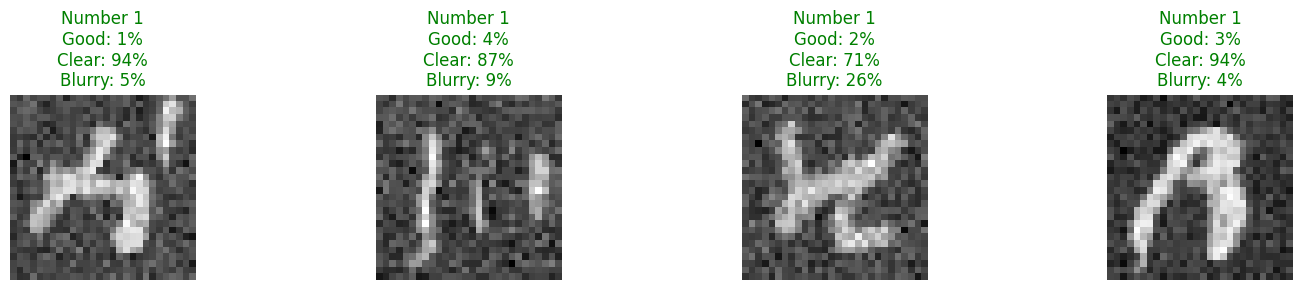


Generating and evaluating number 2...
Generating 4 versions of number 2...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


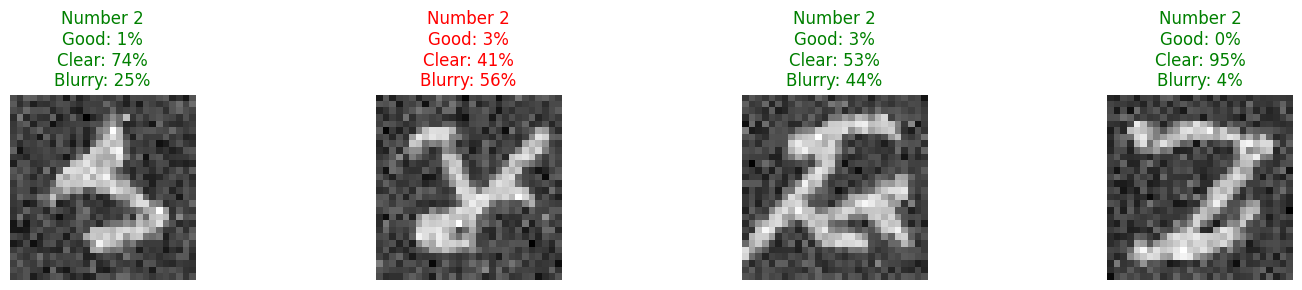


Generating and evaluating number 3...
Generating 4 versions of number 3...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


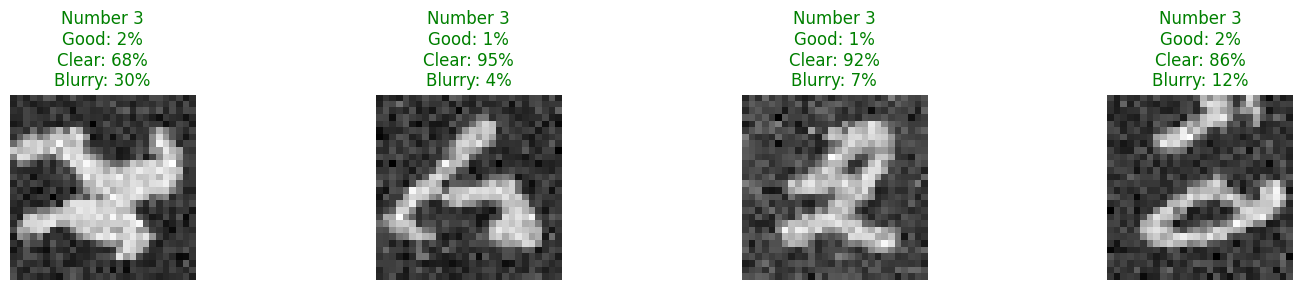


Generating and evaluating number 4...
Generating 4 versions of number 4...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


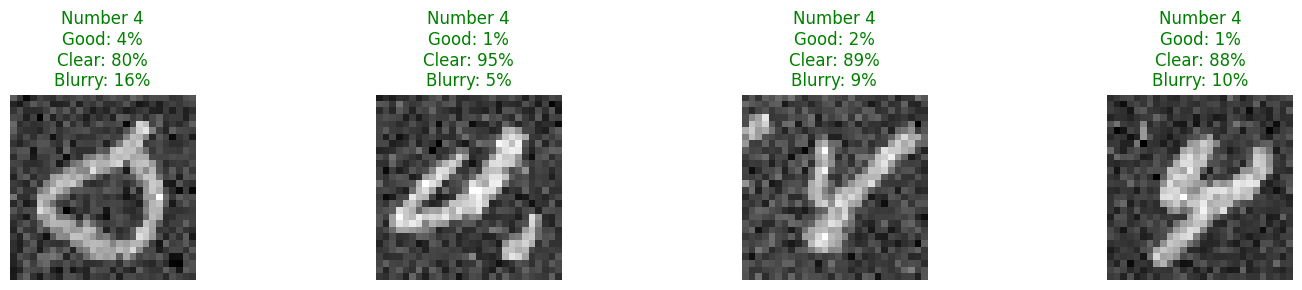


Generating and evaluating number 5...
Generating 4 versions of number 5...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


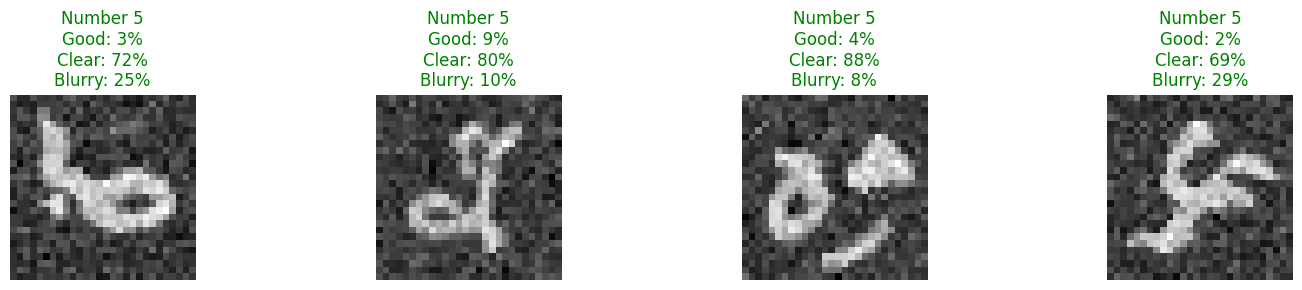


Generating and evaluating number 6...
Generating 4 versions of number 6...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


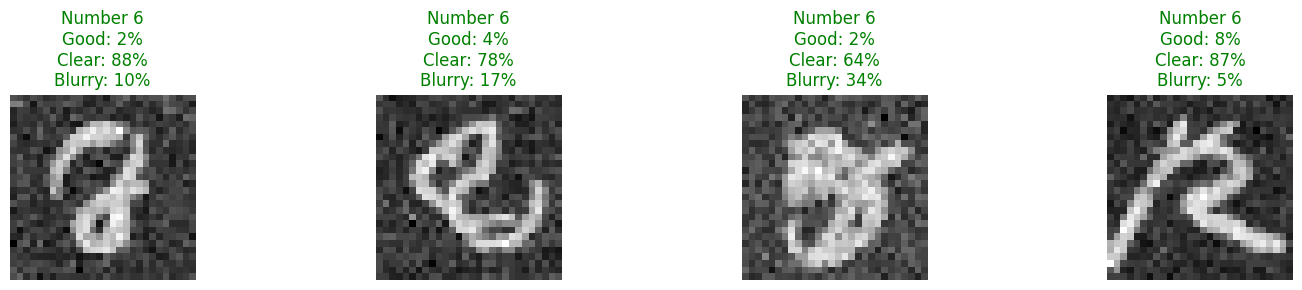


Generating and evaluating number 7...
Generating 4 versions of number 7...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


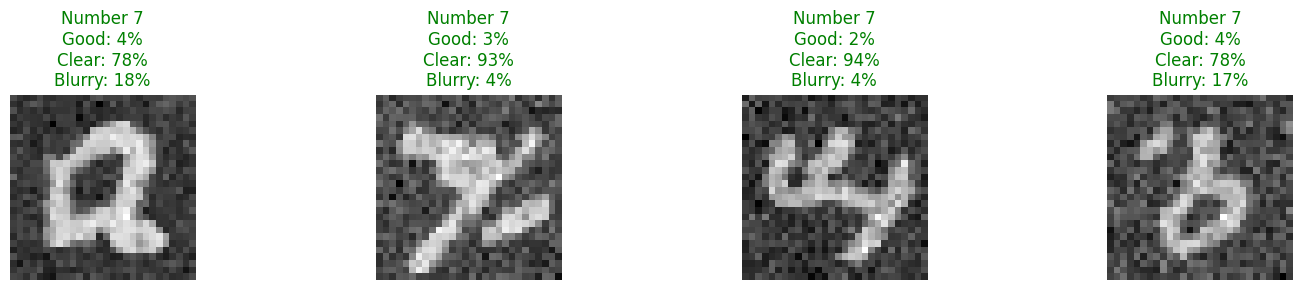


Generating and evaluating number 8...
Generating 4 versions of number 8...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


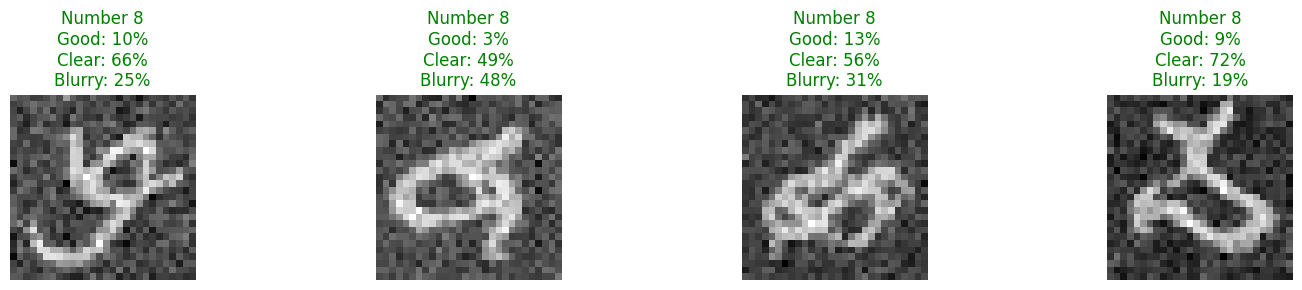


Generating and evaluating number 9...
Generating 4 versions of number 9...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


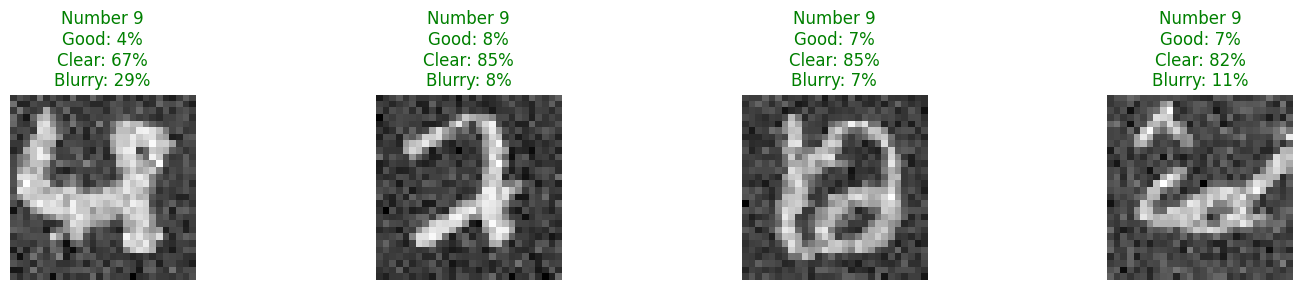


STUDENT ACTIVITY:
Try the code below to evaluate a larger sample of a specific digit

# Example: Generate and evaluate 10 examples of the digit 6
# digit = 6
# samples = generate_number(model, digit, n_samples=10)
# similarities = evaluate_with_clip(samples, digit)
#
# # Calculate what percentage of samples CLIP considers "good quality"
# # (either "good handwritten" or "clear" score exceeds "blurry" score)
# good_or_clear = (similarities[:,0] + similarities[:,1] > similarities[:,2]).float().mean()
# print(f"CLIP recognized {good_or_clear.item()*100:.1f}% of the digits as good examples of {digit}")
#
# # Display a grid of samples with their quality scores
# plt.figure(figsize=(15, 8))
# for i in range(len(samples)):
#     plt.subplot(2, 5, i+1)
#     plt.imshow(samples[i][0].cpu(), cmap='gray')
#     quality = "Good" if similarities[i,0] + similarities[i,1] > similarities[i,2] else "Poor"
#     plt.title(f"Sample {i+1}: {quality}", color='green' if quality == "Good" else 'red')
#     

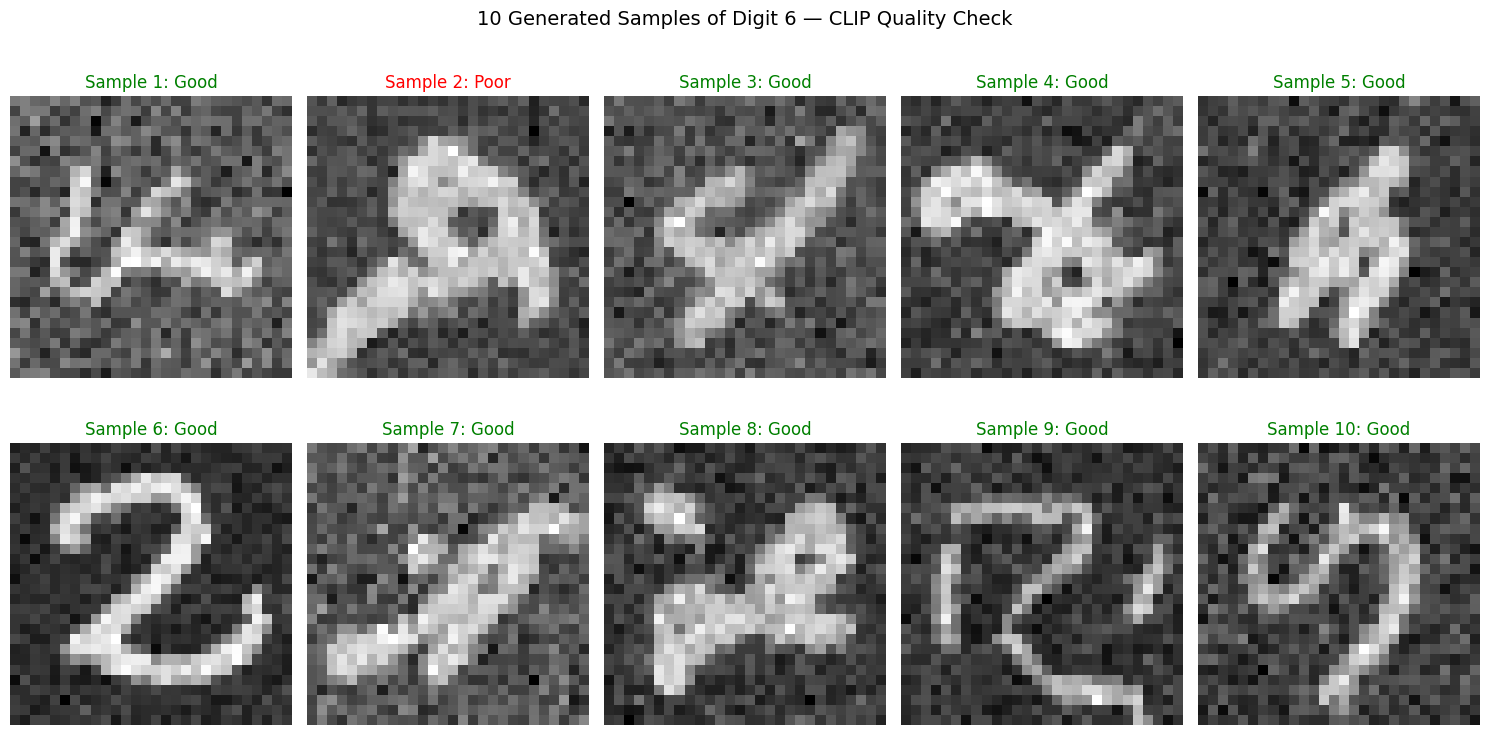

In [30]:
#==============================================================================
# Step 8: CLIP Model Loading and Evaluation Setup
#==============================================================================
# CLIP (Contrastive Language-Image Pre-training) is a neural network that connects
# vision and language. It was trained on 400 million image-text pairs to understand
# the relationship between images and their descriptions.
# We use it here as an "evaluation judge" to assess our generated images.

# Load CLIP model with error handling
try:
    # Load the ViT-B/32 CLIP model (Vision Transformer-based)
    clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
    print(f"✓ Successfully loaded CLIP model: {clip_model.visual.__class__.__name__}")
except Exception as e:
    print(f"❌ Failed to load CLIP model: {e}")
    clip_available = False
    # Instead of raising an error, we'll continue with degraded functionality
    print("CLIP evaluation will be skipped. Generated images will still be displayed but without quality scores.")

def evaluate_with_clip(images, target_number, max_batch_size=16):
    """
    Use CLIP to evaluate generated images by measuring how well they match textual descriptions.

    This function acts like an "automatic critic" for our generated digits by measuring:
    1. How well they match the description of a handwritten digit
    2. How clear and well-formed they appear to be
    3. Whether they appear blurry or poorly formed

    The evaluation process works by:
    - Converting our images to a format CLIP understands
    - Creating text prompts that describe the qualities we want to measure
    - Computing similarity scores between images and these text descriptions
    - Returning normalized scores (probabilities) for each quality

    Args:
        images (torch.Tensor): Batch of generated images [batch_size, channels, height, width]
        target_number (int): The specific digit (0-9) the images should represent
        max_batch_size (int): Maximum images to process at once (prevents GPU out-of-memory errors)

    Returns:
        torch.Tensor: Similarity scores tensor of shape [batch_size, 3] with scores for:
                     [good handwritten digit, clear digit, blurry digit]
                     Each row sums to 1.0 (as probabilities)
    """
    # If CLIP isn't available, return placeholder scores
    if not clip_available:
        print("⚠️ CLIP not available. Returning default scores.")
        # Equal probabilities (0.33 for each category)
        return torch.ones(len(images), 3).to(device) / 3

    try:
        # For large batches, we process in chunks to avoid memory issues
        # This is crucial when working with big images or many samples
        if len(images) > max_batch_size:
            all_similarities = []

            # Process images in manageable chunks
            for i in range(0, len(images), max_batch_size):
                print(f"Processing CLIP batch {i//max_batch_size + 1}/{(len(images)-1)//max_batch_size + 1}")
                batch = images[i:i+max_batch_size]

                # Use context managers for efficiency and memory management:
                # - torch.no_grad(): disables gradient tracking (not needed for evaluation)
                # - torch.cuda.amp.autocast(): uses mixed precision to reduce memory usage
                with torch.no_grad(), torch.cuda.amp.autocast():
                    batch_similarities = _process_clip_batch(batch, target_number)
                    all_similarities.append(batch_similarities)

                # Explicitly free GPU memory between batches
                # This helps prevent cumulative memory buildup that could cause crashes
                torch.cuda.empty_cache()

            # Combine results from all batches into a single tensor
            return torch.cat(all_similarities, dim=0)
        else:
            # For small batches, process all at once
            with torch.no_grad(), torch.cuda.amp.autocast():
                return _process_clip_batch(images, target_number)

    except Exception as e:
        # If anything goes wrong, log the error but don't crash
        print(f"❌ Error in CLIP evaluation: {e}")
        print(f"Traceback: {traceback.format_exc()}")
        # Return default scores so the rest of the notebook can continue
        return torch.ones(len(images), 3).to(device) / 3

def _process_clip_batch(images, target_number):
    """
    Core CLIP processing function that computes similarity between images and text descriptions.

    This function handles the technical details of:
    1. Preparing relevant text prompts for evaluation
    2. Preprocessing images to CLIP's required format
    3. Extracting feature embeddings from both images and text
    4. Computing similarity scores between these embeddings

    The function includes advanced error handling for GPU memory issues,
    automatically reducing batch size if out-of-memory errors occur.

    Args:
        images (torch.Tensor): Batch of images to evaluate
        target_number (int): The digit these images should represent

    Returns:
        torch.Tensor: Normalized similarity scores between images and text descriptions
    """
    try:
        # Create text descriptions (prompts) to evaluate our generated digits
        # We check three distinct qualities:
        # 1. If it looks like a handwritten example of the target digit
        # 2. If it appears clear and well-formed
        # 3. If it appears blurry or poorly formed (negative case)
        text_inputs = torch.cat([
            clip.tokenize(f"A handwritten number {target_number}"),
            clip.tokenize(f"A clear, well-written digit {target_number}"),
            clip.tokenize(f"A blurry or unclear number")
        ]).to(device)

        # Process images for CLIP, which requires specific formatting:

        # 1. Handle different channel configurations (dataset-dependent)
        if IMG_CH == 1:
            # CLIP expects RGB images, so we repeat the grayscale channel 3 times
            # For example, MNIST/Fashion-MNIST are grayscale (1-channel)
            images_rgb = images.repeat(1, 3, 1, 1)
        else:
            # For RGB datasets like CIFAR-10/CelebA, we can use as-is
            images_rgb = images

        # 2. Normalize pixel values to [0,1] range if needed
        # Different datasets may have different normalization ranges
        if images_rgb.min() < 0:  # If normalized to [-1,1] range
            images_rgb = (images_rgb + 1) / 2  # Convert to [0,1] range

        # 3. Resize images to CLIP's expected input size (224x224 pixels)
        # CLIP was trained on this specific resolution
        resized_images = F.interpolate(images_rgb, size=(224, 224),
                                      mode='bilinear', align_corners=False)

        # Extract feature embeddings from both images and text prompts
        # These are high-dimensional vectors representing the content
        image_features = clip_model.encode_image(resized_images)
        text_features = clip_model.encode_text(text_inputs)

        # Normalize feature vectors to unit length (for cosine similarity)
        # This ensures we're measuring direction, not magnitude
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # Calculate similarity scores between image and text features
        # The matrix multiplication computes all pairwise dot products at once
        # Multiplying by 100 scales to percentage-like values before applying softmax
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

        return similarity

    except RuntimeError as e:
        # Special handling for CUDA out-of-memory errors
        if "out of memory" in str(e):
            # Free GPU memory immediately
            torch.cuda.empty_cache()

            # If we're already at batch size 1, we can't reduce further
            if len(images) <= 1:
                print("❌ Out of memory even with batch size 1. Cannot process.")
                return torch.ones(len(images), 3).to(device) / 3

            # Adaptive batch size reduction - recursively try with smaller batches
            # This is an advanced technique to handle limited GPU memory gracefully
            half_size = len(images) // 2
            print(f"⚠️ Out of memory. Reducing batch size to {half_size}.")

            # Process each half separately and combine results
            # This recursive approach will keep splitting until processing succeeds
            first_half = _process_clip_batch(images[:half_size], target_number)
            second_half = _process_clip_batch(images[half_size:], target_number)

            # Combine results from both halves
            return torch.cat([first_half, second_half], dim=0)

        # For other errors, propagate upward
        raise e

#==============================================================================
# CLIP Evaluation - Generate and Analyze Sample Digits
#==============================================================================
# This section demonstrates how to use CLIP to evaluate generated digits
# We'll generate examples of all ten digits and visualize the quality scores

try:
    for number in range(10):
        print(f"\nGenerating and evaluating number {number}...")

        # Generate 4 different variations of the current digit
        samples = generate_number(model, number, n_samples=4)

        # Evaluate quality with CLIP (without tracking gradients for efficiency)
        with torch.no_grad():
            similarities = evaluate_with_clip(samples, number)

        # Create a figure to display results
        plt.figure(figsize=(15, 3))

        # Show each sample with its CLIP quality scores
        for i in range(4):
            plt.subplot(1, 4, i+1)

            # Display the image with appropriate formatting based on dataset type
            if IMG_CH == 1:  # Grayscale images (MNIST, Fashion-MNIST)
                plt.imshow(samples[i][0].cpu(), cmap='gray')
            else:  # Color images (CIFAR-10, CelebA)
                img = samples[i].permute(1, 2, 0).cpu()  # Change format for matplotlib
                if img.min() < 0:  # Handle [-1,1] normalization
                    img = (img + 1) / 2  # Convert to [0,1] range
                plt.imshow(img)

            # Extract individual quality scores for display
            # These represent how confidently CLIP associates the image with each description
            good_score = similarities[i][0].item() * 100  # Handwritten quality
            clear_score = similarities[i][1].item() * 100  # Clarity quality
            blur_score = similarities[i][2].item() * 100   # Blurriness assessment

            # Color-code the title based on highest score category:
            # - Green: if either "good handwritten" or "clear" score is highest
            # - Red: if "blurry" score is highest (poor quality)
            max_score_idx = torch.argmax(similarities[i]).item()
            title_color = 'green' if max_score_idx < 2 else 'red'

            # Show scores in the plot title
            plt.title(f'Number {number}\nGood: {good_score:.0f}%\nClear: {clear_score:.0f}%\nBlurry: {blur_score:.0f}%',
                      color=title_color)
            plt.axis('off')

        plt.tight_layout()
        plt.show()
        plt.close()  # Properly close figure to prevent memory leaks

        # Clean up GPU memory after processing each number
        # This is especially important for resource-constrained environments
        torch.cuda.empty_cache()

except Exception as e:
    # Comprehensive error handling to help students debug issues
    print(f"❌ Error in generation and evaluation loop: {e}")
    print("Detailed error information:")
    import traceback
    traceback.print_exc()

    # Clean up resources even if we encounter an error
    if torch.cuda.is_available():
        print("Clearing GPU cache...")
        torch.cuda.empty_cache()

#==============================================================================
# STUDENT ACTIVITY: Exploring CLIP Evaluation
#==============================================================================
# This section provides code templates for students to experiment with
# evaluating larger batches of generated digits using CLIP.

print("\nSTUDENT ACTIVITY:")
print("Try the code below to evaluate a larger sample of a specific digit")
print("""
# Example: Generate and evaluate 10 examples of the digit 6
# digit = 6
# samples = generate_number(model, digit, n_samples=10)
# similarities = evaluate_with_clip(samples, digit)
#
# # Calculate what percentage of samples CLIP considers "good quality"
# # (either "good handwritten" or "clear" score exceeds "blurry" score)
# good_or_clear = (similarities[:,0] + similarities[:,1] > similarities[:,2]).float().mean()
# print(f"CLIP recognized {good_or_clear.item()*100:.1f}% of the digits as good examples of {digit}")
#
# # Display a grid of samples with their quality scores
# plt.figure(figsize=(15, 8))
# for i in range(len(samples)):
#     plt.subplot(2, 5, i+1)
#     plt.imshow(samples[i][0].cpu(), cmap='gray')
#     quality = "Good" if similarities[i,0] + similarities[i,1] > similarities[i,2] else "Poor"
#     plt.title(f"Sample {i+1}: {quality}", color='green' if quality == "Good" else 'red')
#     plt.axis('off')
# plt.tight_layout()
# plt.show()
""")

# Running the student activity: generate 10 examples of digit 6 and evaluate with CLIP
digit = 6
samples = generate_number(model, digit, n_samples=10)
similarities = evaluate_with_clip(samples, digit)

# What percentage does CLIP consider good quality
good_or_clear = (similarities[:,0] + similarities[:,1] > similarities[:,2]).float().mean()
print(f"CLIP recognized {good_or_clear.item()*100:.1f}% of the digits as good examples of {digit}")

# Show the samples with their scores
plt.figure(figsize=(15, 8))
for i in range(len(samples)):
    plt.subplot(2, 5, i+1)
    plt.imshow(samples[i][0].cpu(), cmap='gray')
    quality = "Good" if similarities[i,0] + similarities[i,1] > similarities[i,2] else "Poor"
    plt.title(f"Sample {i+1}: {quality}", color='green' if quality == "Good" else 'red')
    plt.axis('off')
plt.suptitle(f"10 Generated Samples of Digit {digit} — CLIP Quality Check", fontsize=14)
plt.tight_layout()
plt.show()

## Assessment Questions

Now that you've completed the exercise, answer these questions include explanations, observations, and your analysis
Support your answers with specific examples from your experiments:

### 1. Understanding Diffusion
- Explain what happens during the forward diffusion process, using your own words and referencing the visualization examples from your notebook.

The forward process takes a clean digit and adds small amounts of noise at each of 100 timesteps. Beta starts at 0.0001 and goes up to 0.02 so the noise gets heavier as you go. In the noise progression plot the digit was clear at the start, grainy by about 25%, hard to read at 50%, and pure static past 75%. The math is x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 minus alpha_bar_t) * noise, so the further along you go the less original image is left.

- Why do we add noise gradually instead of all at once? How does this affect the learning process?

Going from pure noise to a clean image in one step would be way too hard to learn. With 100 small steps each one is a simpler problem. Step 99 deals with rough shapes, step 1 just cleans up edges. It's basically a divide and conquer thing.

- Look at the step-by-step visualization - at what point (approximately what percentage through the denoising process) can you first recognize the image? Does this vary by image?

From the visualizations of digits 0, 3, and 7 I could tell what the number was around 60 to 70% through. Before that it's just blobs. The 7 was interesting because the horizontal bar appeared first then the downstroke filled in after. I think simpler shapes like 1 probably emerge sooner but I only visualized those three so I can't say for sure.

### 2. Model Architecture
- Why is the U-Net architecture particularly well-suited for diffusion models? What advantages does it provide over simpler architectures?

The output must be the same size as the input (28x28 in, 28x28 out). The U-Net encoder reduces the image size (28 to 14 to 7) to capture the overall context, then the decoder enlarges it again. A simple convolutional stack would lose spatial information and be unable to recover it. The symmetric structure makes sense for this type of task.

- What are skip connections and why are they important? Explain them in relations to our model

In my model they link matching encoder and decoder layers. So the encoder output at 14x14 goes straight to the decoder at 14x14 by concatenation in the UpBlocks. When you compress to 7x7 you lose fine detail, and skip connections let the decoder get it back directly instead of trying to reconstruct from scratch. Without them the outputs would probably be pretty blurry.

- Describe in detail how our model is conditioned to generate specific images. How does the class conditioning mechanism work?

The digit label gets one-hot encoded (digit 3 becomes [0,0,0,1,0,0,0,0,0,0]), goes through the EmbedBlock which is basically two Linear layers with GELU in between, gets reshaped, and is added to feature maps at the 7x7 bottleneck. So the class info flows through the whole decoder path and the model knows what digit it's supposed to be generating.

### 3. Training Analysis (20 points)
- What does the loss value tell of your model tell us?

The loss is MSE between predicted and actual noise, so lower means the model is getting better at figuring out what noise was added. The very first step started at 1.1178 which is pretty high but it dropped fast. Epoch 1 averaged 0.1001, and by epoch 30 it was down to 0.0558. Best validation loss was 0.0552 saved at epoch 28. The training stats showed a 44.3% improvement from start to finish which I think is solid. The val/train ratio ended at 1.001 so basically no overfitting at all. The model has 1,518,737 parameters but only needed about 23 MB of GPU memory.

- How did the quality of  your  generated images change change throughout the training process?

I could see the samples at each epoch since the notebook generates them during training. In the first couple epochs what I saw was mostly noise with vague shapes trying to form. Around epoch 7 the digits started looking real. By epoch 13 or so they were clearly recognizable. The learning rate dropped from 0.001 to 0.0005 at epoch 26 which seemed to help squeeze out a bit more quality toward the end. The final samples after all 30 epochs looked solid, the simpler digits like 0 and 1 were cleanest and something like 8 was rougher but still readable.

- Why do we need the time embedding in diffusion models? How does it help the model understand where it is in the denoising process?

The task is totally different depending on the noise level. High timestep means tons of noise so the model needs to focus on basic shapes. Low timestep means it's almost clean and just needs to fix small stuff. We used sinusoidal embeddings with a dimension of 8, and that gets fed into the middle of the network. Without this the model would try to do the same correction every time which obviously wouldn't work.

### 4. CLIP Evaluation (20 points)
- What do the CLIP scores tell you about your generated images? Which  images got  the highest and lowest quality scores?

CLIP compares each image against three text descriptions: "a handwritten number [X]", "a clear well-written digit [X]", and "a blurry or unclear number". The scores show as percentages in the plot titles, green if the positive descriptions win and red if blurry wins. Most of my generated digits scored green so CLIP thought they looked like real handwritten numbers. Simple shapes like 0, 1, 7 tended to do better.

- Develop a hypothesis explaining why certain images might be easier or harder for the model to generate convincingly.

I think it's about shape complexity. A 1 is basically just a line, hard to mess up. An 8 needs two proportioned loops and if they're even slightly off it looks weird. Some digits also overlap visually (5 and 3, or 9 and 4 depending on handwriting style) so the model can kind of hedge between them and produce something ambiguous.

- How could CLIP scores be used to improve the diffusion model's generation process? Propose a specific technique.

Generate a bunch of samples per digit and use CLIP to rank them, keep the top ones and discard the rest. I actually tried this in the student activity section where I generated 10 samples of digit 6 and ran CLIP on them. CLIP recognized 90.0% as good examples, and in the grid you can see the ones marked "Good" had cleaner strokes and better proportions than the one marked "Poor". So it works as a quality filter.

### 5. Practical Applications (20 points)
- How could this type of model be useful in the real world?

Generating synthetic training data when real examples are scarce, that's the first thing that comes to mind. Testing handwriting recognition systems with generated samples. And the bigger versions of this same idea basically power the image generators everyone uses today.

- What are the limitations of our current model?

Only 28x28 grayscale. 100 forward passes per image which is slow. Small architecture (32/64/128 channels, 3 levels). Only 10 digit classes. Would need major scaling for anything beyond simple digits.

- If you were to continue developing this project, what three specific improvements would you make and why?

First, generate in fewer steps. Maybe skip every other step to cut generation time in half, the quality probably wouldn't drop that much. Second, make the model bigger (something like 64/128/256 channels) for more capacity. Third, try CIFAR-10 since MNIST is kind of a solved problem at this point and the notebook already has the code set up for it.

### Bonus Challenge (Extra 20 points)
Try one or more of these experiments:
1. If you were to continue developing this project, what three specific improvements would you make and why?

Answered in section 5.

2. Modify the U-Net architecture (e.g., add more layers, increase channel dimensions) and train the model. How do these changes affect training time and generation quality?

Didn't get to try this one.

3. CLIP-Guided Selection: Generate 10 samples of each image, use CLIP to evaluate them, and select the top 3 highest-quality examples of each. Analyze patterns in what CLIP considers "high quality."

I ran this for digit 6 in the student activity section at the bottom of the CLIP cell. Generated 10 samples and evaluated them all with CLIP. The result was that CLIP recognized 90.0% of them as good examples of 6. Looking at the grid, the samples that scored "Good" had cleaner and more centered strokes. The one that scored "Poor" had thicker messier lines and the loop wasn't as well formed. So CLIP seems to prefer clean geometry and good proportions over anything else.

4. tyle Conditioning: Modify the conditioning mechanism to generate multiple styles of the same digit (e.g., slanted, thick, thin). Document your approach and results.

Didn't attempt this.


Deliverables:
1. A PDF copy of your notebook with
    - Complete code, outputs, and generated images
    - Include all experiment results, training plots, and generated samples
    - CLIP evaluation scores of ythe images you generated
    - Answers and any interesting findings from the bonus challenges